We are going to implement a code for Linear Quadratic Control problem 

Loss function = $\mathbb{E}\bigg[\int_0^T(aX_t^2+bX_t+Au_t^2+Bu_t)dt+\alpha X_T^2+\beta X_T\bigg]$


State Process $dX_{t}=(cX_t+du_t)dt+\sigma dB_t$

The HJB equation is given by

$0=\partial_t V(t,x)+\frac{\sigma^2}{2}\partial_x^2V(t,x) +cx\partial_xV(t,x)+ax^2+bx+\inf_u\Big[Au^2+\Big(B+d\partial_xV(t,x)\Big)u\Big]$

$V(T,x)=\alpha x^2+\beta x$.

The optimal solution solution obtained as
$u^*=-\frac{B+d\partial_xV(t,x)}{2A}$
depends on the value function $V(t,x)$, which is the solution of the following PDE
$0=\partial_t V(t,x)+\frac{\sigma^2}{2}\partial_x^2V(t,x) +cx\partial_xV(t,x)+ax^2+bx-\frac{\big(B+d\partial_xV(t,x)\big)^2}{4A}$

$V(T,x)=\alpha x^2+\beta x$.

In [1]:
import numpy as np
import time
from scipy import misc
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font = font_manager.FontProperties(style='normal', size=20)
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
torch.set_default_dtype(torch.float64)
import random
import math
import pandas as pd
from scipy.optimize import fsolve
# from scipy.integrate import solve_ivp # type: ignore
import scipy.integrate as integrate

import json

from IPython.display import display, Math, Markdown
import seaborn as sns
sns.set(font_scale = 2)

import pandas as pd
import datetime
import os
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
timestamp
version = '_8'

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/3215957732.py:3: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


# Three steps

# Different choices for sample numbers

For $2$-fold PGM and $N=5$, one can choose $R\approx2$, $I_2=\frac{3}{5}$, $I_3=\frac{1}{6}$, $g_3=\frac{1}{2}$, $0<\dfrac{g_1}{25}<\frac{g_2}{5}<\frac{1}{2}$. Hence,

$\dfrac{c_{1}J_{1}}{cJ}=g_1,~~\dfrac{c_{2}I_{2}J_{2}}{cJ}=g_1-\dfrac{g_2}{5}~~\text{and}~\dfrac{c_{3}I_{3}J_{3}}{cJ}=\frac{1}{2}-\dfrac{g_2}{5}, ~\text{ with } 0<\frac{g_1}{5}<{g_2}<\frac{5}{2}$.

$J=100$, Time =$160$ seconds

| $g_1$ | $g_2$ | $J_1$ | $J_2$ | $J_3$ | Time | 
| --- | --- | --- | --- | --- | --- |
| $1$ | $\frac{59}{24}$ | $100$ | $50$ | $5$ | $10 + 77 + 7 = 94$ | 

In [2]:
(1/2-7/25)*6, 59/24 

(1.3199999999999998, 2.4583333333333335)

# Parameters

In [3]:
# lqsc_params = {
#     'T':1,
#     'a':0.1,
#     'b':0.1,
#     'c':-1,
#     'd':1,
#     'A':1,
#     'B':1,
#     'sigma':0.5,
#     'alpha':1,
#     'beta':1,
#     'gamma':0.0,
#     }
lqsc_params = {
    'T':1,
    'a':100,
    'b':0.1,
    'c':1.5,
    'd':-1.,
    'A':0.1,
    'B':0.1,
    'sigma':0.5,
    'alpha':0.1,
    'beta':0.1,
    'gamma':0.0
    }

# Function class

In [4]:
class func(object):
    def __init__(self, lqsc_params):
        self.alpha = lqsc_params['alpha']
        self.beta = lqsc_params['beta']
        self.gamma = lqsc_params['gamma']
        self.A = lqsc_params['A']
        self.B = lqsc_params['B']
        self.a = lqsc_params['a']
        self.b = lqsc_params['b']
        self.c = lqsc_params['c']
        self.d = lqsc_params['d']
        self.T = lqsc_params['T']
        self.sigma = lqsc_params['sigma']

    
class term(func):
    def __init__(self, lqsc_params): 
        super(term, self).__init__(lqsc_params)
        self.fnc = lambda tx: self.alpha*torch.pow(tx[:,1],2)+self.beta*tx[:,1]+self.gamma
    def __call__(self,tx):
            return self.fnc(tx)
        
class solution(func):
    def __init__(self, lqsc_params):
        super(solution, self).__init__(lqsc_params)
        q0=self.a
        q1=2*self.c
        q2 = -self.d**2/self.A
        lb1=0.5*(q1+np.sqrt(q1**2-4*q0*q2))
        lb2 = -lb1+q1
        C1 = -(lb1+q2*self.alpha)/(lb2+q2*self.alpha)
        C2 = self.beta*(1+C1)-self.b*(1/(lb1-self.c)+C1/(lb2-self.c))+self.B/self.d*(lb1/(lb1-self.c)+C1*lb2/(lb2-self.c))
        self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
        self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb1*(self.T-t))+C1*(1/(lb2-self.c))*np.exp(lb2*(self.T-t)))-self.B/self.d*((lb1/(lb1-self.c))*np.exp(lb1*(self.T-t))+C1*(lb2/(lb2-self.c))*np.exp(lb2*(self.T-t)))+C2*np.exp(self.c*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
        self.integrand = lambda t: self.sigma**2*self.f_func(self.T-t) -(self.B+self.d*self.h_func(self.T-t))**2/(4*self.A)
        self.k_func = lambda t: integrate.quad(lambda x: self.integrand(x), 0, self.T-t)[0]        
    def __call__(self,tx):
            return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
    def optimal_policy(self,tx):
            return np.array([2*self.f_func(tx[i,0])*tx[i,1]+self.h_func(tx[i,0]) for i in range(tx.shape[0])])      

In [5]:
t1 = term(lqsc_params)
input=torch.tensor([[0,1],[1,.2]])
t1(input)#,lqsc.loss_func_ter(input)

tensor([0.2000, 0.0240])

# Closed-from solution for LQSC

In [6]:
solution = solution(lqsc_params)

We assume that the value function is quadratic in $x$,

$V(t,x)=f(t)x^2+h(t)x+k(t)$. 

By substituting $V$ in the HJB PDE we get the following system of Riccati ODE.

$0=f'+a+2cf-\frac{d^2}{A}f^2;  f(T)=\alpha$

$0=h'+b-\frac{(B+dh)d}{A}f;  h(T)=\beta$

$0=k'+\sigma^2 f-\frac{1}{4A}(B+dh)^2;  k(T)=\gamma$

By solving this system of first order ODE we can get $f,h,t$ in closed form and we obtain the optimal solution as

$u^*=-\frac{B+d(2xf(t)+h(t))}{2A}$

First let's write all equations forward and then change $t$ to $T-t$ at the end.

$f'=a+2cf-\frac{d^2}{A}f^2;  f(0)=\alpha$

$h'=b-\frac{(B+dh)d}{A}f;  h(0)=\beta$

$k'=\sigma^2 f-\frac{1}{4A}(B+dh)^2;  k(0)=\gamma$

$f$ satisfies a Riccati ODE: $f(t)=-\dfrac{1}{q_2}\dfrac{\lambda_1 e^{\lambda_1 t}+C\lambda_2 e^{\lambda_2 t}}{ e^{\lambda_1 t}+C e^{\lambda_2 t}}$ with

$C=-\dfrac{\lambda_1+q_2\alpha}{\lambda_2+q_2\alpha}$, $q_2=-\dfrac{d^2}{A}$, $q_1=2c$, $q_0=a$, $\lambda_1=\dfrac{q_1+\sqrt{q_1^2-2q_0q_2}}{2}$, and $\lambda_2=\dfrac{q_1-\sqrt{q_1^2-2q_0q_2}}{2}$


$h'=b-\frac{Bd}{A}f+(c-\frac{d^2}{A}f)h = b-\frac{Bd}{A}f+(c+q_2f)h ;  h(0)=\beta$

$h'-(c+q_2f)h= b-\frac{Bd}{A}f$


$\left( e^{-(ct+q_2\int fdt)}h\right)'= e^{-ct-q_2\int fdt}(b-\frac{Bd}{A}f)$


In the process of finding $f$, we note that $f = -\dfrac{U'(t)}{q_2U(t)}$, where $U(t)=e^{\lambda_1 t}+Ce^{\lambda_2 t}$. Thus,

$-q_2\int f dt = \ln U(t)$ and $e^{-q_2\int fdt}=U(t)$.


$e^{-ct}U(t) h(t) = \int e^{-cs}U(s)(b-\frac{Bd}{A}f(s))ds = \int e^{-ct}U(s)(b+\frac{Bd}{A}\dfrac{U'(s)}{q_2U(s)})ds= \int e^{-cs}(U(s)b-\frac{B}{d}{U'(s)})ds$


$h(t) =  \dfrac{e^{ct}}{U(t)}\int e^{-cs}(U(s)b+\frac{B}{d}{U'(s)})ds= \dfrac{b(\frac{1}{\lambda_1-c}e^{\lambda_1 t}+C\frac{1}{\lambda_2-c}e^{\lambda_2t} )-\frac{B}{d}(\frac{\lambda_1}{\lambda_1-c}e^{\lambda_1t}+C\frac{\lambda_2}{\lambda_2-c}e^{\lambda_2t})+C_2 e^{ct}}{U(t)}$, where $C_2$ is such that $h(0)=\beta$:

$C_2=\beta(1+C)-b(\frac{1}{(\lambda_1-c)}+\frac{C}{(\lambda_2-c)})+\frac{B}{d}(\frac{\lambda_1}{(\lambda_1-c)}+C\frac{\lambda_2}{(\lambda_2-c)})$

For $k'=\sigma^2 f-\frac{1}{4A}(B+dh)^2;  k(0)=0$:

$\sigma^2\int f dt = -\dfrac{\sigma^2}{q_2}\ln U(t) +C_3$


To find $\int (B+dh)^2 dt$ note that $B+dh=b\dfrac{\frac{1}{\lambda_1}e^{\lambda_1 t}+C\frac{1}{\lambda_2}e^{\lambda_2 t}+C_2}{U(t)}$

$\int (B+dh)^2 dt=b^2\displaystyle\int \left(\dfrac{\frac{1}{\lambda_1}e^{\lambda_1 t}+C\frac{1}{\lambda_2}e^{\lambda_2 t}+C_2}{U(t)}\right)^2dt=b^2\displaystyle\int \dfrac{(\frac{1}{\lambda_1}e^{\lambda_1 t}+C\frac{1}{\lambda_2}e^{\lambda_2 t})^2}{U^2(t)}dt+2b^2C_2\displaystyle\int \dfrac{\frac{1}{\lambda_1}e^{\lambda_1 t}+C\frac{1}{\lambda_2}e^{\lambda_2 t}}{U^2(t)}dt+C^2_2\displaystyle\int \dfrac{1}{U^2(t)}dt$ 

The above three integrals are evaluated here:

https://www.wolframalpha.com/input?i=%5Cint+%28n+%2B+c+me%5E%7Bbt%7D%29%2F%28%281%2B+c+e%5E%7Bbt%7D%29%5E2%29dt

https://www.wolframalpha.com/input?i=%5Cint+%28%28n+%2B+c+me%5E%7Bbt%7D%29%5E2%29%2F%28%281%2B+c+e%5E%7Bbt%7D%29%5E2%29dt

https://www.wolframalpha.com/input?i=%5Cint+1%2F%28%28e%5E%7Bat%7D%2B+c+e%5E%7Bbt%7D%29%5E2%29dt







# PGM

## PGM parameters

In [7]:
# model_params = {
#     'num_samples':100,
#     'num_time_steps':20,
#     'num_neurons_p':50,
#     'num_neurons_v':10,
#     'lr' : 8e-3,
#     'num_epochs' : 3000,
#     'xmin' : 0.,
#     'xmax' : 1.,
#     'intervals' : None # a list of numbers between 0 to num_intervals-1
#     }
# model_params = {
#     'num_samples':100,
#     'num_time_steps':10,
#     'num_neurons_p':50,
#     'num_neurons_v':10,
#     'lr' : 8e-3,
#     'num_epochs' : 3000,
#     'xmin' : -1.,
#     'xmax' : 1.,
#     'intervals' : None # a list of numbers between 0 to num_intervals-1
#     }
model_params = {
    'num_samples':100,
    'num_time_steps':5,
    'num_neurons_p':50,
    'num_neurons_v':10,
    'lr' : 8e-3,
    'num_epochs' : 3000,
    'xmin' : -10.,
    'xmax' : 10.,
    'intervals' : None # a list of numbers between 0 to num_intervals-1
    }

## PGM class

In [8]:
class pgm(object):
    def __init__(self, model_params, lqsc_params, fnc, **kwargs):
        self.value_eval = kwargs.get('value_eval', True)
        self.num_samples = model_params['num_samples']
        self.num_time_steps = model_params['num_time_steps']
        self.num_neurons_p = model_params['num_neurons_p']
        self.num_neurons_v = model_params['num_neurons_v']
        self.lr = model_params['lr']
        self.num_epochs = model_params['num_epochs']
        self.x0 = model_params['xmin']
        self.x1 = model_params['xmax']
        self.Num_steps = self.num_time_steps
        self.T = lqsc_params['T']
        self.delta = torch.tensor(self.T/self.num_time_steps)
        self.a=lqsc_params['a']
        self.b=lqsc_params['b']
        self.c=lqsc_params['c']
        self.d=lqsc_params['d']
        self.A=lqsc_params['A']
        self.B=lqsc_params['B']
        self.sigma=lqsc_params['sigma']
        self.alpha=lqsc_params['alpha']
        self.beta=lqsc_params['beta']
        self.gamma=lqsc_params['gamma']
        self.fnc = fnc#lambda tx: self.alpha*torch.pow(tx[:,1],2)+self.beta*tx[:,1]+self.gamma
        self.proper_int = lambda t: int((self.T-t)/self.delta)+1 if (self.T-t)/self.delta - int((self.T-t)/self.delta) > self.delta/2 else int((self.T-t)/self.delta)


        self.model= torch.nn.Sequential(
            torch.nn.Linear(2, self.num_neurons_p),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_p, self.num_neurons_p),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_p,1)
        )
        self.value= torch.nn.Sequential(
            torch.nn.Linear(2, self.num_neurons_v),
            torch.nn.Tanh(),
            torch.nn.Linear(self.num_neurons_v, self.num_neurons_v),
            torch.nn.Tanh(),
            torch.nn.Linear(self.num_neurons_v,1)
        )
        
        
    def gen_data(self):
        self.t=torch.zeros([self.num_samples,1])
        self.z= torch.normal(0, 1, size=(self.num_samples,self.num_time_steps+1))
        self.x_train=torch.FloatTensor(self.num_samples,1).uniform_(self.x0,self.x1)   #remaining balance R_t   #To get a positive solution R_t has to be greater than D_t
        self.data=torch.cat((self.t,self.x_train),dim=1)
    
    def update(self,x3,psi,i):
        t=(x3[:,0]+self.delta)
        x=x3[:,1]+(self.c*x3[:,1]+self.d*psi)*self.delta+self.sigma*torch.sqrt(self.delta)*self.z[:,i]
        up=torch.cat((t.unsqueeze(1),x.unsqueeze(1)),dim=1)
        return up

    def loss_func(self,x2,psi):
        loss=self.a*torch.pow(x2[:,1],2)+self.b*x2[:,1]+self.A*torch.pow(psi,2)+self.B*psi
        return loss

    def loss_func_ter(self,x4):
        # loss=self.alpha*torch.pow(x4[:,1],2)+self.beta*x4[:,1]
        return self.fnc(x4)#loss

    def unit(self,x1,i,policy, **kwargs):
        x2 = kwargs.get('disc_policy', x1)
        psi=policy(x2).squeeze(1)
        loss=self.loss_func(x1,psi)
        upd=self.update(x1,psi,i)
        #print('unit print=',psi.shape,los.shape,upd.shape)
        return psi,loss,upd

    def loss_func_total(self,epoch):
        u = self.data
        path = torch.zeros(self.num_samples,self.num_time_steps+1,2)
        path_loss=torch.zeros(self.num_samples,self.num_time_steps+1)
        psi=torch.zeros(self.num_samples,self.num_time_steps)
        if (epoch==self.num_epochs-1):
            self.state_var=u.clone().detach()
            path[:,0,:] = u.clone().detach()
        for i in range(self.num_time_steps):
            psi_run,loss_run,u_run=self.unit(u,i,self.model)
            #print('los func=',psi_run.shape,loss_run.shape)
            path_loss[:,i]=loss_run*self.delta
            #print(loss)
            psi[:,i]=psi_run
            #print(psi)
            u=u_run
            if (epoch==self.num_epochs-1):
                self.state_var = torch.concat((self.state_var,u.clone().detach()), axis=0)      
                path[:,i+1,:] =   u.clone().detach()    
        path_loss[:,-1]=self.loss_func_ter(u)
        if (epoch==self.num_epochs-1):
            a = torch.flip(path_loss, dims = (1,))
            b = torch.cumsum(a, dim=1)
            c = torch.flip(b, dims = (1,))
            d = torch.transpose(c,0,1)
            self.path_cost = d.reshape((self.num_time_steps+1)*self.num_samples,1).clone().detach()
            p = torch.transpose(path,0,1)
            self.path = p.reshape((self.num_time_steps+1)*self.num_samples,2).clone().detach()
        loss_=torch.sum(path_loss,dim=1)
        return loss_
    
    def train_it(self):
        self.gen_data()
        start=time.time()
        cost_ar=[]
        optimizer = optim.Adam(self.model.parameters(), self.lr)
        for epoch in range(self.num_epochs):
            optimizer.zero_grad()
            cost = self.loss_func_total(epoch)
            loss = torch.mean(cost)
            loss.backward()
            optimizer.step()
            cost_ar.append(loss)
            #print(loss.item())
            if (epoch % 500==0):
                print("At epoch {} the mean cost is {}.".format(epoch,loss.detach()))
        end=time.time()
        total_time=end-start
        print('Training time=',total_time)
        if self.value_eval:
            self.train_val_fnc()
    
    def policy(self,tx):
        return self.model(tx)
    
    def train_val_fnc(self,**kwargs):
        M = kwargs.get('num_epochs', self.num_epochs)
        K = kwargs.get('num_samples', self.num_samples)
        permuted_range = np.random.permutation((self.num_time_steps+1)*K)
        num_batches = int((K-1)/50) + 1
        epoch_cut = int(M/num_batches)
        tx = self.path[permuted_range,:]
        val = self.path_cost[permuted_range,:]
        optimizer_v = optim.Adam(self.value.parameters(), self.lr)
        start=time.time()
        E_ = -1e9
        E = 1e9
        m = 0
        i = -1
        while (np.abs((E-E_)/E_)>1e-6) and ( m <= M):
            i = int(m/epoch_cut)
        # for _ in range(M):
            r = range(i*50*(self.num_time_steps+1),min((i+1)*50*(self.num_time_steps+1),(self.num_time_steps+1)*K))
            loss_v = torch.nn.MSELoss()(self.value(tx[r,:]),val[r,:])
            optimizer_v.zero_grad()
            loss_v.backward()
            optimizer_v.step()
            E_ = E
            E = loss_v.clone().detach().numpy().item()
            m += 1
        end=time.time()
        print("Last training epoch was {:d}".format(m))
        total_time=end-start
        print('value function training time=',total_time)
        
    def cost_eval(self,policy,num_samples,x0, **kwargs):
        M = kwargs.get('policy_update_lag', 1)
        if  self.num_time_steps%M!=0:
            raise ValueError(r"The number of time steps {:d} in this PGM instance must be divisible by the number of time steps {:d} in the input of disc_cost_eval(self,policy,num_samples,num_time_steps,x0).".format(self.num_time_steps,M))
        else:
            N = self.num_time_steps+1
            val=torch.zeros([num_samples])
            t=torch.zeros([num_samples,1])
            self.z= torch.normal(0, 1, size=(num_samples,N))
            x = x0*torch.ones([num_samples,1])
            full_path = torch.zeros(num_samples,N,2)
            full_path[:,0,:] = torch.cat((t,x),dim=1).clone().detach()
            for i in range(N-1):
                last_coarse_point = full_path[:,int(i/M),:]
                _,loss_run,u_run=self.unit(full_path[:,i,:],i,policy,disc_policy = last_coarse_point)
                full_path[:,i+1,:] = u_run.clone().detach() 
                val += (loss_run*self.delta).clone().detach()
            val += self.loss_func_ter(u_run).clone().detach()
            return torch.mean(val)     
    
    # We need the policy to only be evaluated at discrete points and stays unchanged until the next point.
    # def alt_value(self,num_samples,t,x):
    #     M = x.shape[0]
    #     x0 = x.repeat(num_samples).unsqueeze(-1)
    #     t0 = t.repeat(num_samples*M).unsqueeze(-1)
    #     N = self.proper_int(t) 
    #     full_path = torch.zeros(num_samples*M,N+1,2)
    #     # full_path_loss=torch.zeros(M,num_samples,N)
    #     self.z= torch.normal(0, 1, size=(M*num_samples,N))
    #     val=torch.zeros(num_samples*M)
    #     full_path[:,0,:] = torch.cat((t0,x0),dim=1).clone().detach()
    #     for i in range(N):
    #         _,loss_run,u_run=self.unit(full_path[:,i,:],i,self.policy)
    #         full_path[:,i+1,:] = u_run.clone().detach() 
    #         val += (loss_run*self.delta).clone().detach()
    #     # print(N,t)
    #     val += self.loss_func_ter(u_run).clone().detach()
    #     w = torch.reshape(val,[num_samples,M])
    #     return torch.mean(w,axis=0)
    
    def __call__(self,tx):
        return self.value(tx).squeeze(-1)

     


## Instance creation

In [9]:
lqsc = pgm(model_params,lqsc_params, t1)

## Training

In [10]:
lqsc.train_it()

At epoch 0 the mean cost is 13183.008579021436.


At epoch 500 the mean cost is 715.0086032201388.


At epoch 1000 the mean cost is 714.9896434673967.


At epoch 1500 the mean cost is 714.9788455166748.


At epoch 2000 the mean cost is 714.9663271431209.


At epoch 2500 the mean cost is 714.9546896944443.


Training time= 3.379788875579834


Last training epoch was 3001
value function training time= 0.7438697814941406


[0.00,0.20]: MSE=115.732074, Hausdorff=9.214201
[0.20,0.40]: MSE=1.640365, Hausdorff=0.248022
[0.40,0.60]: MSE=2.441302, Hausdorff=0.071297
[0.60,0.80]: MSE=0.063589, Hausdorff=0.151146
[0.80,1.00]: MSE=1.162035, Hausdorff=0.115273


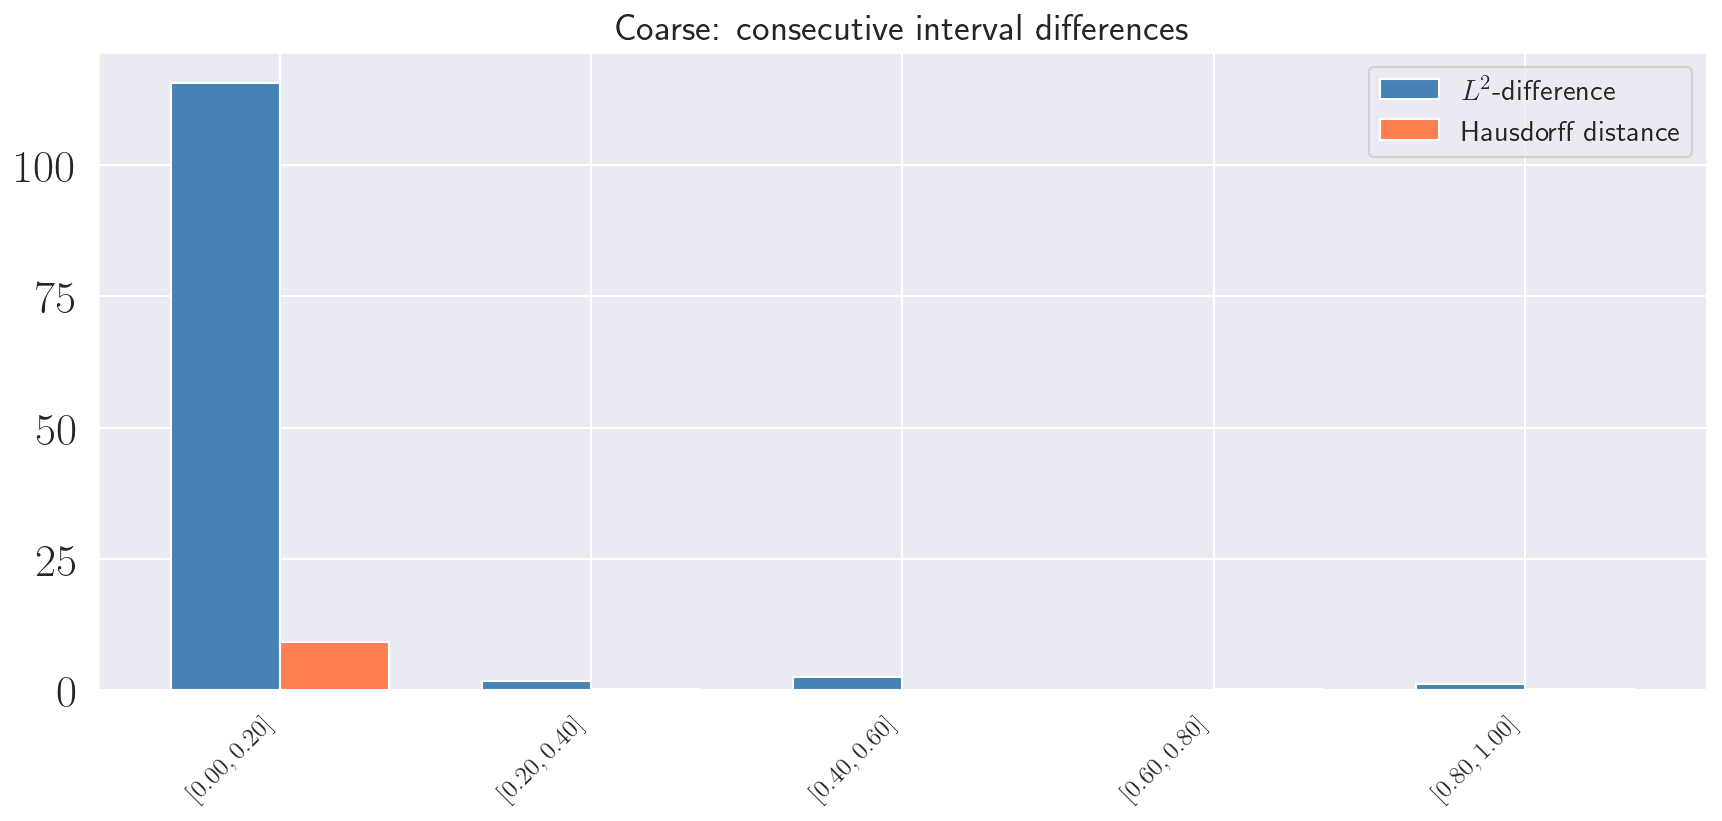

In [11]:
# L2 and Hausdorff difference between consecutive coarse intervals
from scipy.spatial.distance import directed_hausdorff
import numpy as np

path = lqsc.path.clone().detach()

x_ranges = {}
x_data = {}
for t_val in sorted(set(path[:, 0].numpy().round(8))):
    mask = torch.abs(path[:, 0] - t_val) < 1e-5
    xs = path[mask, 1]
    if len(xs) > 0:
        x_ranges[t_val] = (xs.min().item(), xs.max().item())
        x_data[t_val] = xs.numpy().reshape(-1, 1)

times = sorted(x_ranges.keys())
mse_list = []
hausdorff_list = []
labels = []
num_grid = 200
for i in range(len(times) - 1):
    ta, tb = times[i], times[i + 1]
    x_lo = max(x_ranges[ta][0], x_ranges[tb][0])
    x_hi = min(x_ranges[ta][1], x_ranges[tb][1])
    if x_lo < x_hi:
        x_grid = torch.linspace(x_lo, x_hi, num_grid)
        tx0 = torch.cat((ta * torch.ones(num_grid, 1), x_grid.unsqueeze(-1)), dim=1)
        tx1 = torch.cat((tb * torch.ones(num_grid, 1), x_grid.unsqueeze(-1)), dim=1)
        v0 = lqsc.value(tx0).squeeze(-1).detach()
        v1 = lqsc.value(tx1).squeeze(-1).detach()
        mse = torch.mean((v0 - v1) ** 2).item()
    else:
        mse = 0
    mse_list.append(mse)
    d_fwd = directed_hausdorff(x_data[ta], x_data[tb])[0]
    d_bwd = directed_hausdorff(x_data[tb], x_data[ta])[0]
    hausdorff_list.append(max(d_fwd, d_bwd))
    labels.append(f"$[{ta:.2f},{tb:.2f}]$")
    print(f"[{ta:.2f},{tb:.2f}]: MSE={mse:.6f}, Hausdorff={hausdorff_list[-1]:.6f}")

x_pos = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
ax.bar(x_pos - width/2, mse_list, width, label=r"$L^2$-difference", color='steelblue')
ax.bar(x_pos + width/2, hausdorff_list, width, label='Hausdorff distance', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)
ax.set_title('Coarse: consecutive interval differences', fontsize=18)
ax.legend(fontsize=14)
plt.tight_layout()
plt.savefig("/Users/arashfahim/Documents/GitHub/multiscale-PGM-for-stochastic-control/LQC/Three-steps/L2_diff_consecutive_coarse" + version + ".pdf", format='pdf')
plt.show()

In [12]:
# Hausdorff for coarse merged into cell above

In [13]:
K1 = 20
L = 10
X1 = torch.linspace(-2.,2.,K1)
T = torch.zeros([K1,1])
tx1 = torch.concat((T,X1.unsqueeze(-1)),dim=1)
dfv_co = pd.DataFrame(np.zeros([K1*L,2]),columns=[1,'closed']); 
for i,_ in dfv_co.iterrows(): 
    for c in dfv_co.columns:
        if c != 'closed':
            dfv_co.loc[i,c] = lqsc.cost_eval(lqsc.policy,1,X1[i%K1],policy_update_lag=c).clone().detach().numpy()
dfv_co['closed'] = list(solution(tx1))*L
dfv_co['index'] = [str(np.round(x,3)) for x in X1.clone().detach().numpy()]*L
dfv_co.set_index('index',inplace=True,drop=True)
dfv_co


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,closed
index,,
-2.0,83.380261,13.858620
-1.789,70.819069,11.236016
-1.579,60.783294,8.907337
-1.368,42.645955,6.872583
-1.158,33.804157,5.131752
...,...,...
1.158,37.452403,5.381618
1.368,41.293907,7.167879
1.579,54.064466,9.248064


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/2703621577.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/2703621577.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right");


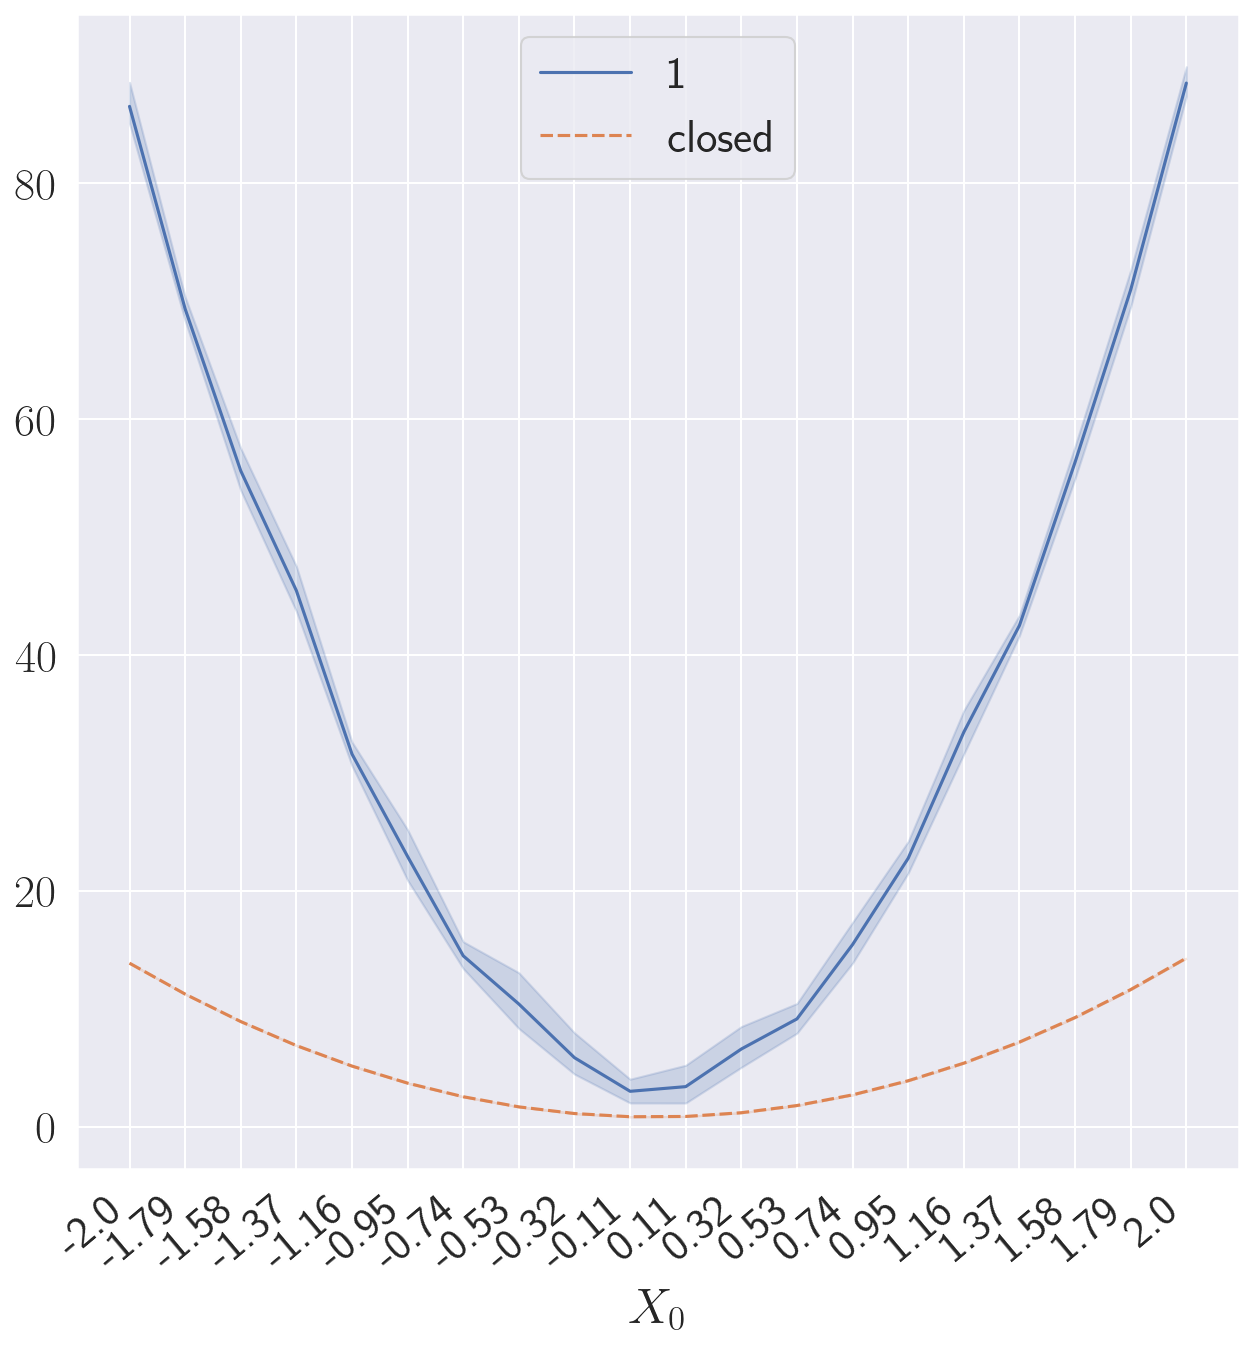

In [14]:
fig = plt.figure(figsize=(10,10),dpi=150);
g = sns.lineplot(data=dfv_co);
g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
g.set_xlabel(r"$X_0$");
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right");



In [15]:
K = 10
L = 10
X = torch.linspace(-10.,10.,K)
T = torch.zeros([K,1])
tx = torch.concat((T,X.unsqueeze(-1)),dim=1)
df_co = pd.DataFrame(np.zeros([K*L,2]),columns=[1,'closed']); 
for i,_ in df_co.iterrows(): 
    for c in df_co.columns:
        if c != 'closed':
            df_co.loc[i,c] = lqsc.cost_eval(lqsc.policy,1,X[i%K],policy_update_lag=c).clone().detach().numpy()
df_co['closed'] = list(solution(tx))*L
df_co['index'] = [str(np.round(x,3)) for x in X.clone().detach().numpy()]*L
df_co.set_index('index',inplace=True,drop=True)
df_co


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,closed
index,,
-10.0,2083.595444,331.315435
-7.778,1257.870389,200.559325
-5.556,647.236489,102.552185
-3.333,232.747711,37.294016
-1.111,31.157554,4.784816
...,...,...
1.111,29.981514,5.024587
3.333,235.325875,38.013328
5.556,651.812855,103.751039


In [16]:
df_box_co = ((df_co[1]-df_co['closed'])/df_co['closed']).reset_index()
df_box_co.columns = ['x', 'rel_error']
df_box_co['Method'] = 'coarse'

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/3061354558.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(list(np.round(X.clone().detach().numpy(),2)));
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/3061354558.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="center");


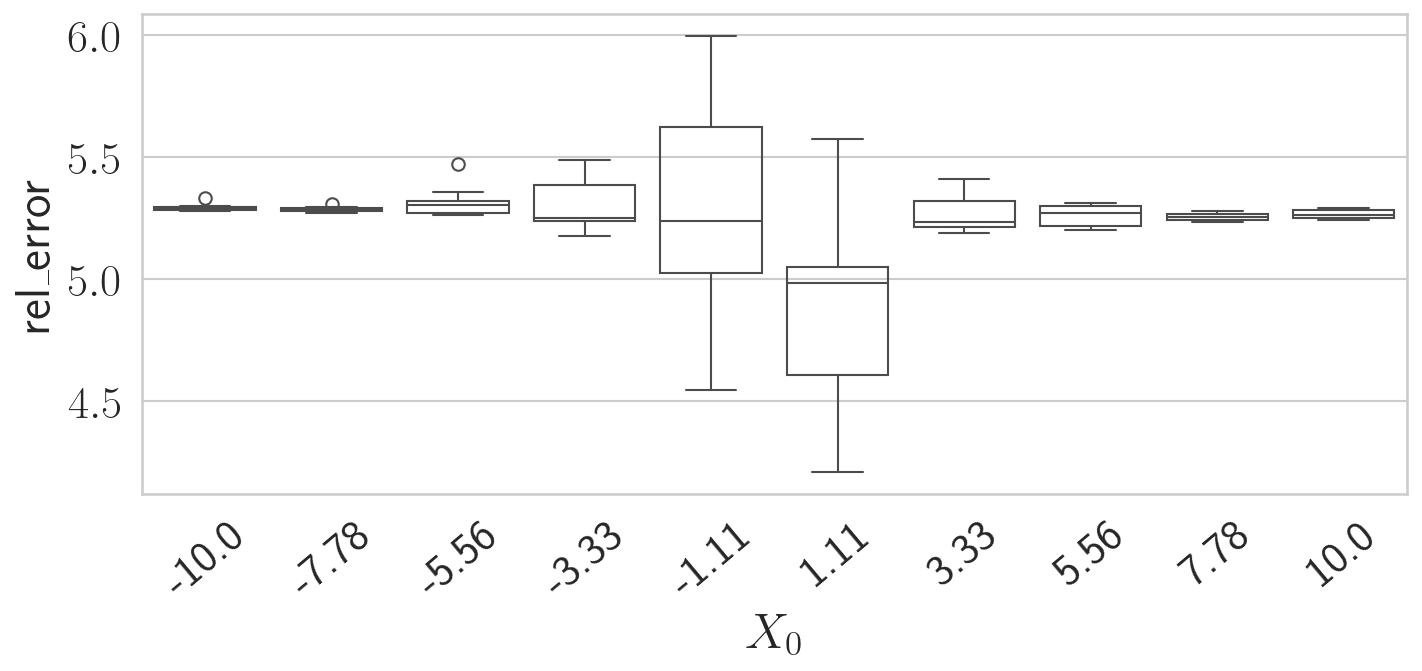

In [17]:
fig = plt.figure(figsize=(10,5),dpi=150);
sns.set_style("whitegrid");
g = sns.boxplot(data=df_box_co, y = 'rel_error', x = 'x', boxprops=dict(facecolor='none'));
g.set_xticklabels(list(np.round(X.clone().detach().numpy(),2)));
g.set_xlabel(r"$X_0$");
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="center");
plt.tight_layout();


In [18]:
lqsc.train_val_fnc(num_epochs=12000)

Last training epoch was 12001
value function training time= 2.948716163635254


Relative $L^1$ error $= 433.78\%$

Relative $L^2$ error $= 406.95\%$

Relative $L^\infty$ error $= 334.27\%$

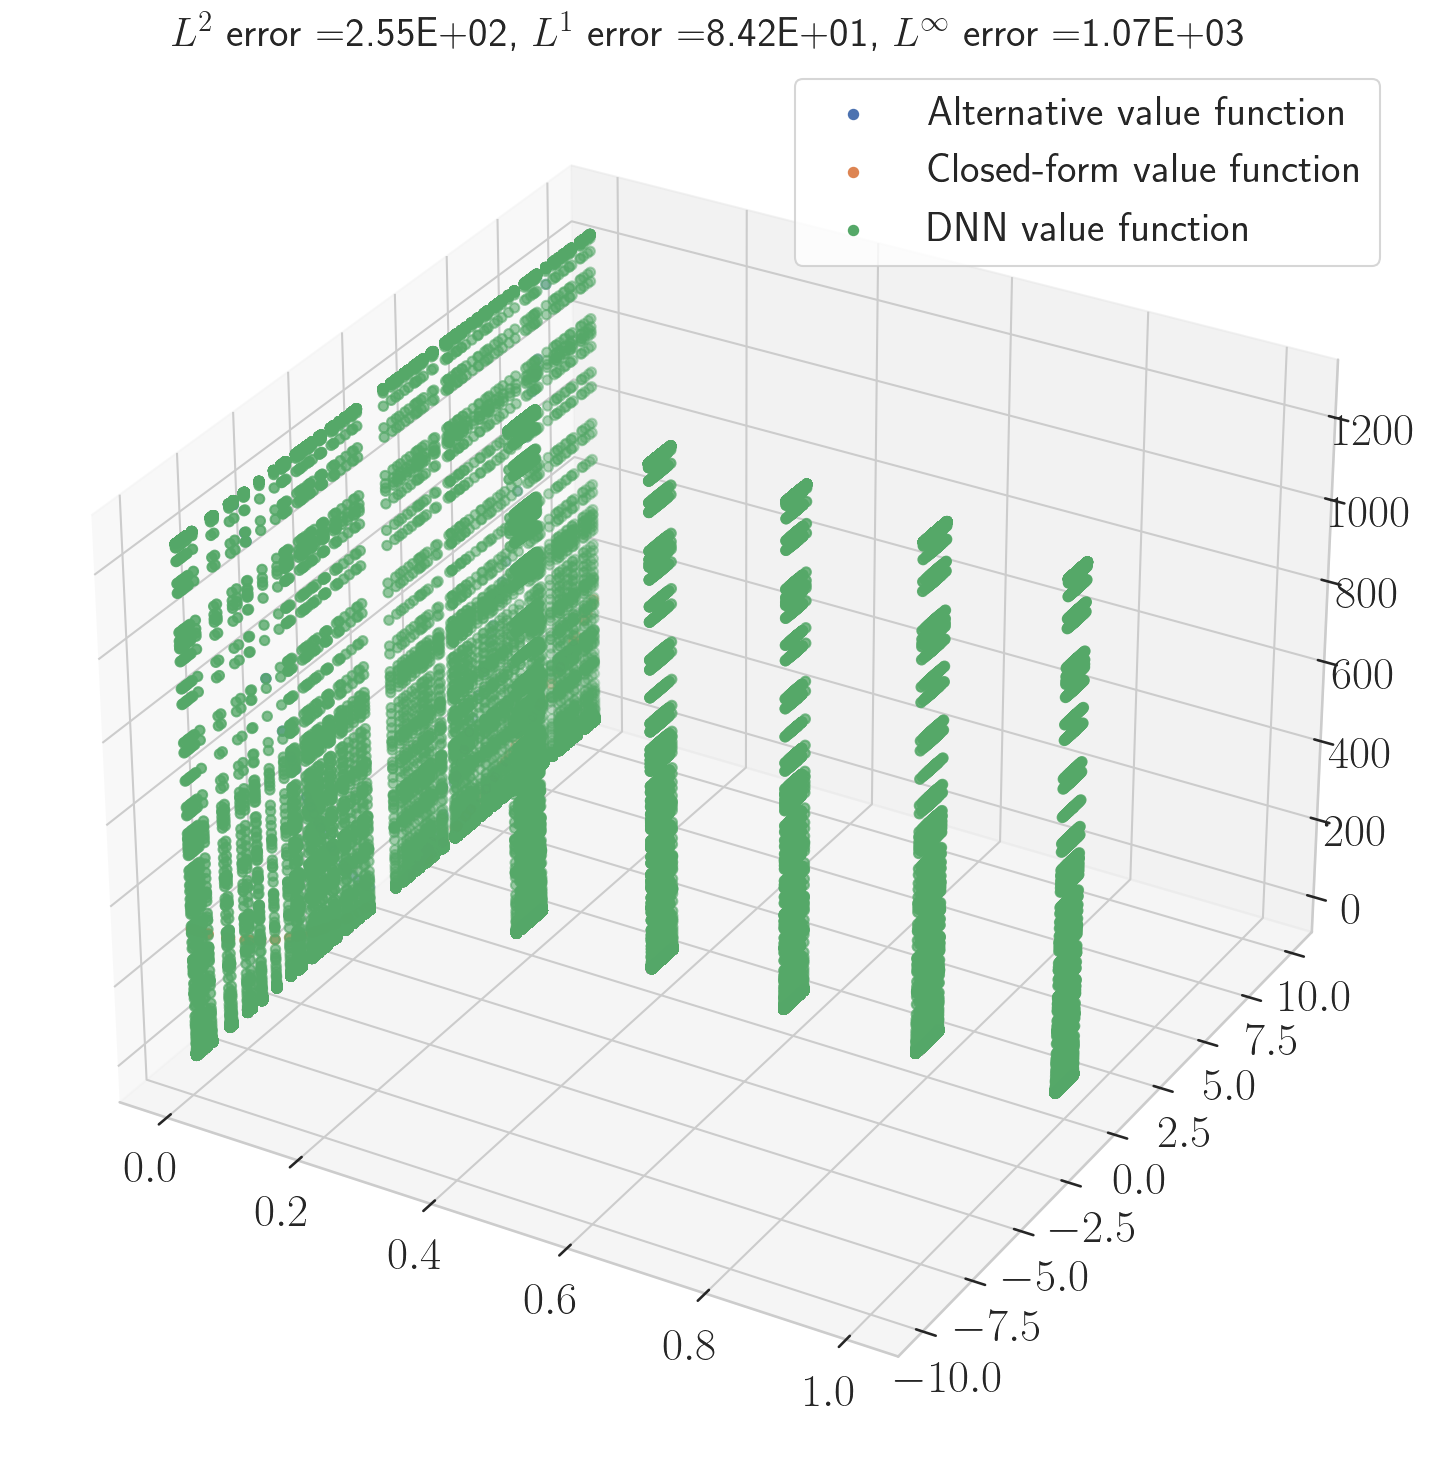

In [19]:
xyz = torch.concat((lqsc.path,lqsc(lqsc.path).unsqueeze(-1)),dim=1).clone().detach().numpy()
v = lqsc.value(lqsc.path).unsqueeze(-1).clone().detach().numpy()
fig = plt.figure(figsize=(12, 12), dpi=150)
ax = fig.add_subplot(projection='3d')
ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2],label='Alternative value function')
ax.scatter(xyz[:,0], xyz[:,1], solution(xyz[:,0:2]),label='Closed-form value function')
ax.scatter(xyz[:,0], xyz[:,1], v,label='DNN value function')

ax.set_title(r"$L^2$ error ={:.2E}, $L^1$ error ={:.2E},  $L^\infty$ error ={:.2E}".format(np.sqrt(np.mean(np.power(solution(xyz[:,0:2])-xyz[:,2],2))),
                                                                                           np.mean(np.abs(solution(xyz[:,0:2])-xyz[:,2])),
                                                                                           np.max(np.abs(solution(xyz[:,0:2])-xyz[:,2]))
                                                                                           ), fontsize=20)
# ax.view_init(elev=30, azim=45, roll=0)
ax.legend(prop=font);
display(Markdown(r"Relative $L^1$ error $= {:.2f}\%$".format(np.mean(np.abs(solution(xyz[:,0:2])-xyz[:,2]))/np.mean(np.abs(solution(xyz[:,0:2])))*100)))
display(Markdown(r"Relative $L^2$ error $= {:.2f}\%$".format(np.sqrt(np.mean(np.power(solution(xyz[:,0:2])-xyz[:,2],2)))/np.sqrt(np.mean(np.power(solution(xyz[:,0:2]),2)))*100)))
display(Markdown(r"Relative $L^\infty$ error $= {:.2f}\%$".format(np.max(np.abs(solution(xyz[:,0:2])-xyz[:,2]))/np.max(np.abs(solution(xyz[:,0:2])))*100)))

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

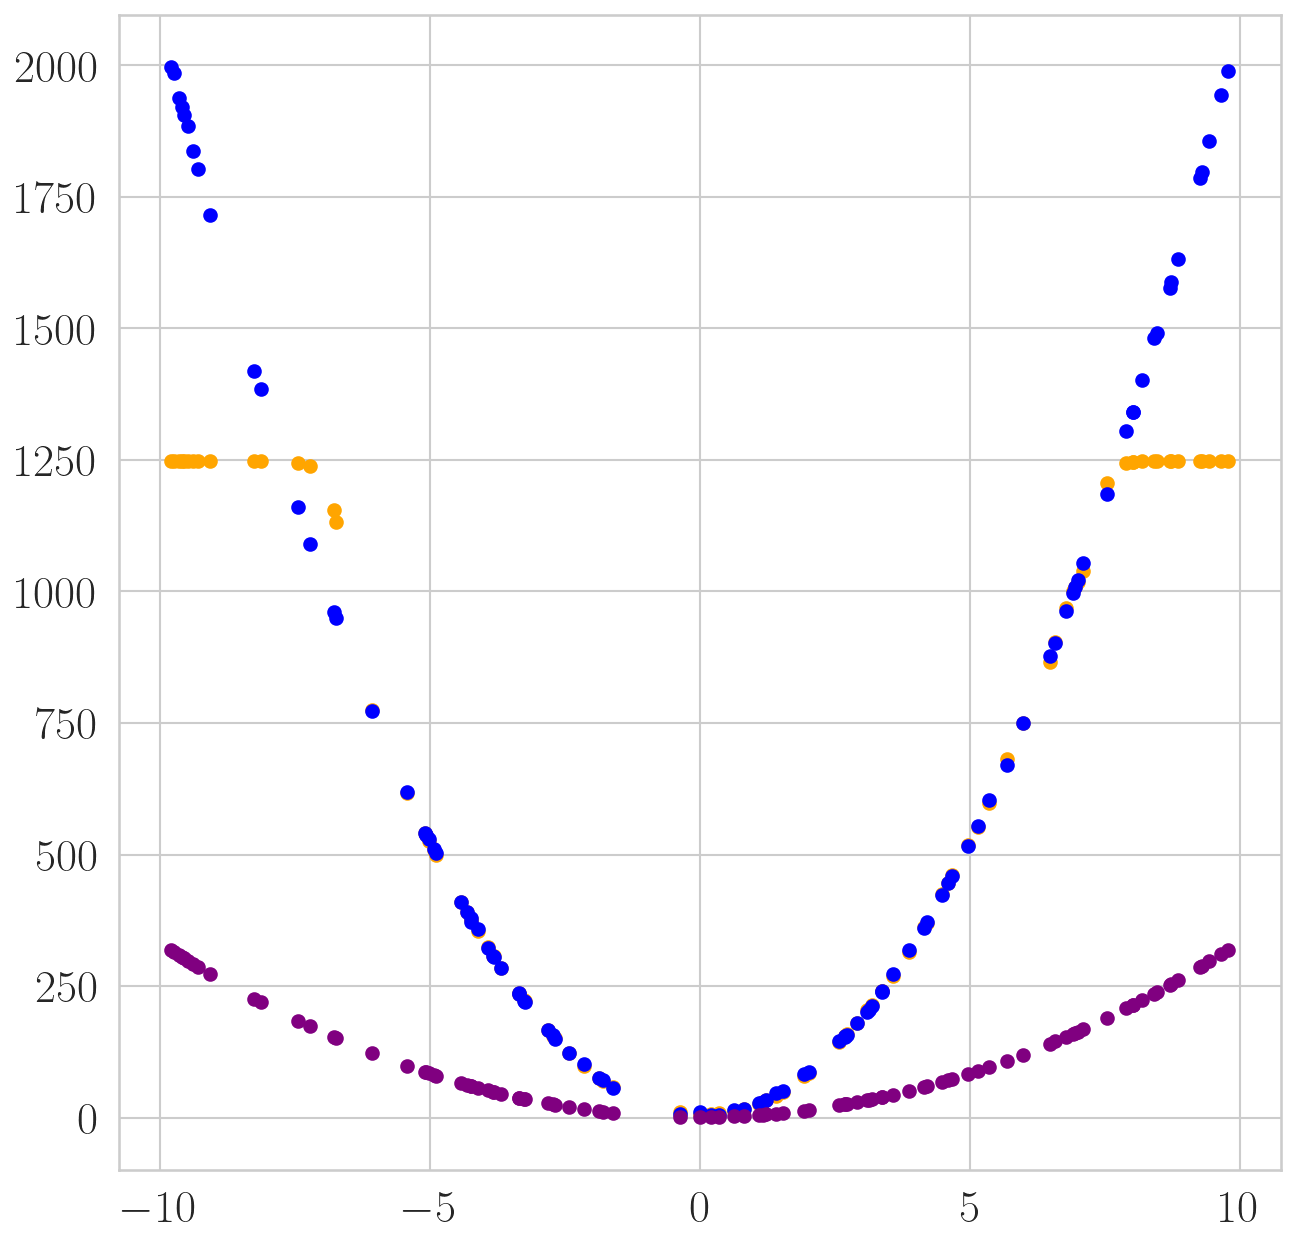

In [20]:
fig = plt.figure(figsize=(10, 10), dpi=150)
x = torch.linspace(-1.,1.,100)
t = torch.Tensor([0.0])
# plt.scatter(x = x.clone().detach().numpy(),y = lqsc.alt_value(500,t,x).clone().detach().numpy(),color='green') 
x = lqsc.path
y = lqsc.value(x)
z = lqsc.path_cost
ind = torch.abs(x[:,0]-t)<1e-3
plt.scatter(x[ind][:,1].clone().detach().numpy(),y[ind].clone().detach().numpy(),color='orange')
plt.scatter(x[ind][:,1].clone().detach().numpy(),z[ind].clone().detach().numpy(),color='blue');
plt.scatter(x[ind][:,1].clone().detach().numpy(),solution(x[ind]),color='purple');

# Multi-scale class

In [21]:
class multi_scale_pgm(object):
    def __init__(self, model_params, lqsc_params, parent, **kwarg):
        self.value_eval = kwarg.get('value_eval', True)
        self.num_samples = model_params['num_samples']
        self.num_time_steps = model_params['num_time_steps']
        self.num_neurons_p = model_params['num_neurons_p']
        self.num_neurons_v = model_params['num_neurons_v']
        self.lr = model_params['lr']
        self.num_epochs = model_params['num_epochs']
        self.x0 = model_params['xmin']
        self.x1 = model_params['xmax']
        self.intervals = [[0,1.]] if model_params['intervals']== None else model_params['intervals']
        self.num_intervals = len(self.intervals)
        self.parent = parent#lambda tx: self.alpha*torch.pow(tx[:,1],2)+self.beta*tx[:,1]+self.gamma
        self.T = self.parent.T
        self.delta = parent.delta/self.num_time_steps
        self.Num_steps = self.parent.Num_steps*self.num_time_steps
        self.a=lqsc_params['a']
        self.b=lqsc_params['b']
        self.c=lqsc_params['c']
        self.d=lqsc_params['d']
        self.A=lqsc_params['A']
        self.B=lqsc_params['B']
        self.sigma=lqsc_params['sigma']
        self.alpha=lqsc_params['alpha']
        self.beta=lqsc_params['beta']
        self.gamma=lqsc_params['gamma']
        self.init_data = model_params['data']
        self.proper_int = lambda t: int((self.T-t)/self.delta)+1 if (self.T-t)/self.delta - int((self.T-t)/self.delta) > self.delta/2 else int((self.T-t)/self.delta)



        self.model= torch.nn.Sequential(
            torch.nn.Linear(2, self.num_neurons_p),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_p, self.num_neurons_p),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_p,1)
        )
        self.value= torch.nn.Sequential(
            torch.nn.Linear(2, self.num_neurons_v),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_v, self.num_neurons_v),
            torch.nn.ReLU(),
            torch.nn.Linear(self.num_neurons_v,1)
        )
        
    
    def gen_data(self):
        if self.intervals == [[0,1.]]:
            self.t=torch.zeros([self.num_samples,self.num_intervals])
            #z=np.zeros([M,ite+1])+np.random.rand(M,1)
            # self.z= torch.normal(0, 1, size=(self.num_samples,self.num_time_steps+1))
            self.x_train=torch.FloatTensor(self.num_samples,1).uniform_(self.x0,self.x1)   #remaining balance R_t   #To get a positive solution R_t has to be greater than D_t
            self.data=torch.cat((self.t,self.x_train),dim=1)
        else:
            x = self.init_data
            for i,I in enumerate(self.intervals):
                if i==0:
                    data = x[torch.abs(x[:,0]-I[0])<1e-3][:,1]
                    a = torch.quantile(data, 0.1, interpolation='linear')
                    b = torch.quantile(data, 0.9, interpolation='linear')
                    self.t=I[0]*torch.ones([self.num_samples,1])
                    self.x_train=torch.FloatTensor(self.num_samples,1).uniform_(a,b)
                    self.data=torch.cat((self.t,self.x_train),dim=1)
                else:
                    data = x[torch.abs(x[:,0]-I[0])<1e-2]
                    a = torch.quantile(data, 0.1, interpolation='linear')
                    b = torch.quantile(data, 0.9, interpolation='linear')
                    self.t=I[0]*torch.ones([self.num_samples,1])
                    self.x_train=torch.FloatTensor(self.num_samples,1).uniform_(a,b)
                    data = torch.cat((self.t,self.x_train),dim=1)
                    self.data = torch.concat((self.data,data))
        self.z= torch.normal(0, 1, size=(self.data.shape[0],self.num_time_steps+1))

    
    def update(self,x3,psi,i):
        t=(x3[:,0]+self.delta)
        x=x3[:,1]+(self.c*x3[:,1]+self.d*psi)*self.delta+self.sigma*torch.sqrt(self.delta)*self.z[:,i]
        up=torch.cat((t.unsqueeze(1),x.unsqueeze(1)),dim=1)
        return up

    def loss_func(self,x2,psi):
        loss=self.a*torch.pow(x2[:,1],2)+self.b*x2[:,1]+self.A*torch.pow(psi,2)+self.B*psi
        return loss

    def loss_func_ter(self,x4):
        # loss=self.alpha*torch.pow(x4[:,1],2)+self.beta*x4[:,1]
        return self.parent(x4)#loss

    def unit(self,x1,i,policy, **kwargs):
        x2 = kwargs.get('disc_policy', x1)
        psi=policy(x2).squeeze(1)
        loss=self.loss_func(x1,psi)
        upd=self.update(x1,psi,i)
        #print('unit print=',psi.shape,los.shape,upd.shape)
        return psi,loss,upd

    def loss_func_total(self,epoch):
        u = self.data
        path = torch.zeros(self.num_samples*self.num_intervals,self.num_time_steps+1,2)
        path_loss=torch.zeros(self.num_samples*self.num_intervals,self.num_time_steps+1)# (i,j)-> (i+1)j
        psi=torch.zeros(self.num_samples*self.num_intervals,self.num_time_steps)
        if (epoch==self.num_epochs-1):
            self.state_var=u.clone().detach()   
            path[:,0,:] = u.clone().detach()
        for i in range(self.num_time_steps):
            psi_run,loss_run,u_run=self.unit(u,i,self.model)
            #print('los func=',psi_run.shape,loss_run.shape)
            path_loss[:,i]=loss_run*self.delta
            #print(loss)
            psi[:,i]=psi_run
            #print(psi)
            u=u_run
            if (epoch==self.num_epochs-1):
                self.state_var = torch.concat((self.state_var,u.clone().detach()), axis=0)  
                path[:,i+1,:] = u.clone().detach()     
        path_loss[:,-1]=self.loss_func_ter(u)
        if (epoch==self.num_epochs-1):
            a = torch.flip(path_loss, dims = (1,))
            b = torch.cumsum(a, dim=1)
            c = torch.flip(b, dims = (1,))
            d = torch.transpose(c,0,1)
            self.path_cost = d.reshape(self.num_intervals*(self.num_time_steps+1)*self.num_samples,1).clone().detach()
            p = torch.transpose(path,0,1)
            self.path = p.reshape(self.num_intervals*(self.num_time_steps+1)*self.num_samples,2).clone().detach()            
        loss_=torch.sum(path_loss,dim=1)
        return loss_
    
    def train_it(self):
        self.gen_data()
        start=time.time()
        cost_ar=[]
        optimizer = optim.Adam(self.model.parameters(), self.lr)
        for epoch in range(self.num_epochs):
            optimizer.zero_grad()
            cost = self.loss_func_total(epoch)
            loss = torch.mean(cost)
            loss.backward()
            optimizer.step()
            cost_ar.append(loss)
            #print(loss.item())
            if (epoch % 500==0):
                print("At epoch {} the mean cost is {}.".format(epoch,loss.detach()))
        end=time.time()
        total_time=end-start
        print('Training time=',total_time)
        self.path_full, self.path_cost_full = self.optimal_path(self.parent.num_samples)

        if self.value_eval:
            self.train_val_fnc()


    def train_val_fnc(self,**kwargs):
        M = kwargs.get('num_epochs', self.num_epochs)
        K = kwargs.get('num_samples', self.num_samples)
        permuted_range = np.random.permutation(self.num_intervals*(self.num_time_steps+1)*self.num_samples)
        tx = self.path_full[permuted_range,:]
        val = self.path_cost_full[permuted_range,:]
        optimizer_v = optim.Adam(self.value.parameters(), self.lr)
        start=time.time()
        E_ = -1e9
        E = 1e9
        m = 0
        while (np.abs((E-E_)/E_)>1e-4) and ( m <= M):
            loss_v = torch.nn.MSELoss()(self.value(tx),val)
            optimizer_v.zero_grad()
            loss_v.backward()
            optimizer_v.step()
            m += 1
        end=time.time()
        total_time=end-start
        print('value function training time=',total_time)        
        
    def __call__(self, tx):
        return self.value(tx).squeeze(-1)
    
    def policy(self,tx):
        return self.model(tx)    
        
    def optimal_path(self,num_samples):
        N = self.Num_steps+1
        path = torch.zeros(num_samples,N,2)
        path_loss=torch.zeros(num_samples,N)
        t=torch.zeros([num_samples,1])
        self.z= torch.normal(0, 1, size=(num_samples,N))
        x=torch.FloatTensor(num_samples,1).uniform_(self.x0,self.x1)   #remaining balance R_t   #To get a positive solution R_t has to be greater than D_t
        path[:,0,:] = torch.cat((t,x),dim=1).clone().detach()
        for i in range(N-1):
            _,loss_run,u_run=self.unit(path[:,i,:],i,self.model)
            path[:,i+1,:] = u_run.clone().detach() 
            path_loss[:,i]=loss_run*self.delta   
        path_loss[:,-1]=self.loss_func_ter(u_run)
        p = torch.transpose(path,0,1)
        path = p.reshape(num_samples*N,2).clone().detach()   
        a = torch.flip(path_loss, dims = (1,))
        b = torch.cumsum(a, dim=1)
        c = torch.flip(b, dims = (1,))
        d = torch.transpose(c,0,1)
        path_cost = d.reshape(num_samples*N,1).clone().detach()         
        return path, path_cost
        

    def cost_eval(self,policy,num_samples,x0, **kwargs):
        M = kwargs.get('policy_update_lag', 1)
        if  self.Num_steps%M!=0:
            raise ValueError(r"The number of time steps {:d} in this PGM instance must be divisible by the number of time steps {:d} in the input of disc_cost_eval(self,policy,num_samples,num_time_steps,x0).".format(self.num_time_steps,M))
        else:
            N = self.Num_steps+1
            val=torch.zeros([num_samples])
            t=torch.zeros([num_samples,1])
            self.z= torch.normal(0, 1, size=(num_samples,N))
            x = x0*torch.ones([num_samples,1])
            full_path = torch.zeros(num_samples,N,2)
            full_path[:,0,:] = torch.cat((t,x),dim=1).clone().detach()
            for i in range(N-1):
                last_coarse_point = full_path[:,int(i/M),:]
                _,loss_run,u_run=self.unit(full_path[:,i,:],i,policy,disc_policy = last_coarse_point)
                full_path[:,i+1,:] = u_run.clone().detach() 
                val += (loss_run*self.delta).clone().detach()
            val += self.parent.loss_func_ter(u_run).clone().detach()
            return torch.mean(val)     
        
        
   # We need the policy to only be evaluated at discrete points and stays unchanged until the next point.
    # def alt_value(self,num_samples,t,x):
    #     M = x.shape[0]
    #     x0 = x.repeat(num_samples).unsqueeze(-1)
    #     t0 = t.repeat(num_samples*M).unsqueeze(-1)
    #     N = self.proper_int(t)
    #     full_path = torch.zeros(num_samples*M,N+1,2)
    #     # full_path_loss=torch.zeros(M,num_samples,N)
    #     self.z= torch.normal(0, 1, size=(M*num_samples,N))
    #     val=torch.zeros(num_samples*M)
    #     full_path[:,0,:] = torch.cat((t0,x0),dim=1).clone().detach()
    #     if N==0:
    #         u_run = full_path[:,0,:]
    #     else:
    #         for i in range(N):
    #             _,loss_run,u_run=self.unit(full_path[:,i,:],i,self.policy)
    #             full_path[:,i+1,:] = u_run.clone().detach() 
    #             val += (loss_run*self.delta).clone().detach()
    #     val += self.loss_func_ter(u_run).clone().detach()
    #     w = torch.reshape(val,[num_samples,M])
    #     return torch.mean(w,axis=0)

    # def __call__(self, tx, **kwargs):
    #     num_samples = kwargs.get('num_samples',500)
    #     t_set = set(tx[:,0].clone().detach().numpy())
    #     val = torch.zeros(tx.shape[0])
    #     for ti in t_set:
    #         ind = tx[:,0] == ti
    #         if ti>=self.T-self.delta/2:
    #             val[ind] = self.loss_func_ter(tx[ind]).clone().detach()
    #         else:
    #             val[ind] = self.alt_value(num_samples,torch.tensor(ti),tx[ind][:,1])
    #     return val                
         
    

# Multi-scale PGM 1

## Multi-scale parameters

In [22]:
ms1_model_params = {
    'num_samples':50,
    'num_time_steps':5,
    'num_neurons_p':50,
    'num_neurons_v':10,
    'lr' : 8e-3,
    'num_epochs' : 3000,
    'xmin' : model_params['xmin'],
    'xmax' : model_params['xmax'],
    'intervals' : [[0, lqsc.T/lqsc.num_time_steps], [(lqsc.num_time_steps-1)*lqsc.T/lqsc.num_time_steps, lqsc.T]], # first + last interval
    'data': lqsc.path
    }

In [23]:
ms1_model_params['intervals']

[[0, 0.2], [0.8, 1]]

## instance creation

In [24]:
ms1 = multi_scale_pgm(ms1_model_params,lqsc_params, lqsc, value_eval=True)

## Training

In [25]:
ms1.train_it()

At epoch 0 the mean cost is 571.492855539922.


At epoch 500 the mean cost is 65.95261825144993.


At epoch 1000 the mean cost is 65.94998048785105.


At epoch 1500 the mean cost is 65.94822198092378.


At epoch 2000 the mean cost is 65.94710527858162.


At epoch 2500 the mean cost is 65.94627875052775.


Training time= 3.0960588455200195


value function training time= 0.4750499725341797


[0.00,0.04]: MSE=0.161060, Hausdorff=5.324685
[0.04,0.08]: MSE=0.012662, Hausdorff=1.602726
[0.08,0.12]: MSE=0.000108, Hausdorff=0.411982
[0.12,0.16]: MSE=0.000098, Hausdorff=0.131273
[0.16,0.20]: MSE=0.000037, Hausdorff=0.096283
[0.80,0.84]: MSE=0.000000, Hausdorff=0.360434
[0.84,0.88]: MSE=0.000000, Hausdorff=0.098058
[0.88,0.92]: MSE=0.000000, Hausdorff=0.130233
[0.92,0.96]: MSE=0.000000, Hausdorff=0.168591
[0.96,1.00]: MSE=0.000000, Hausdorff=0.116110


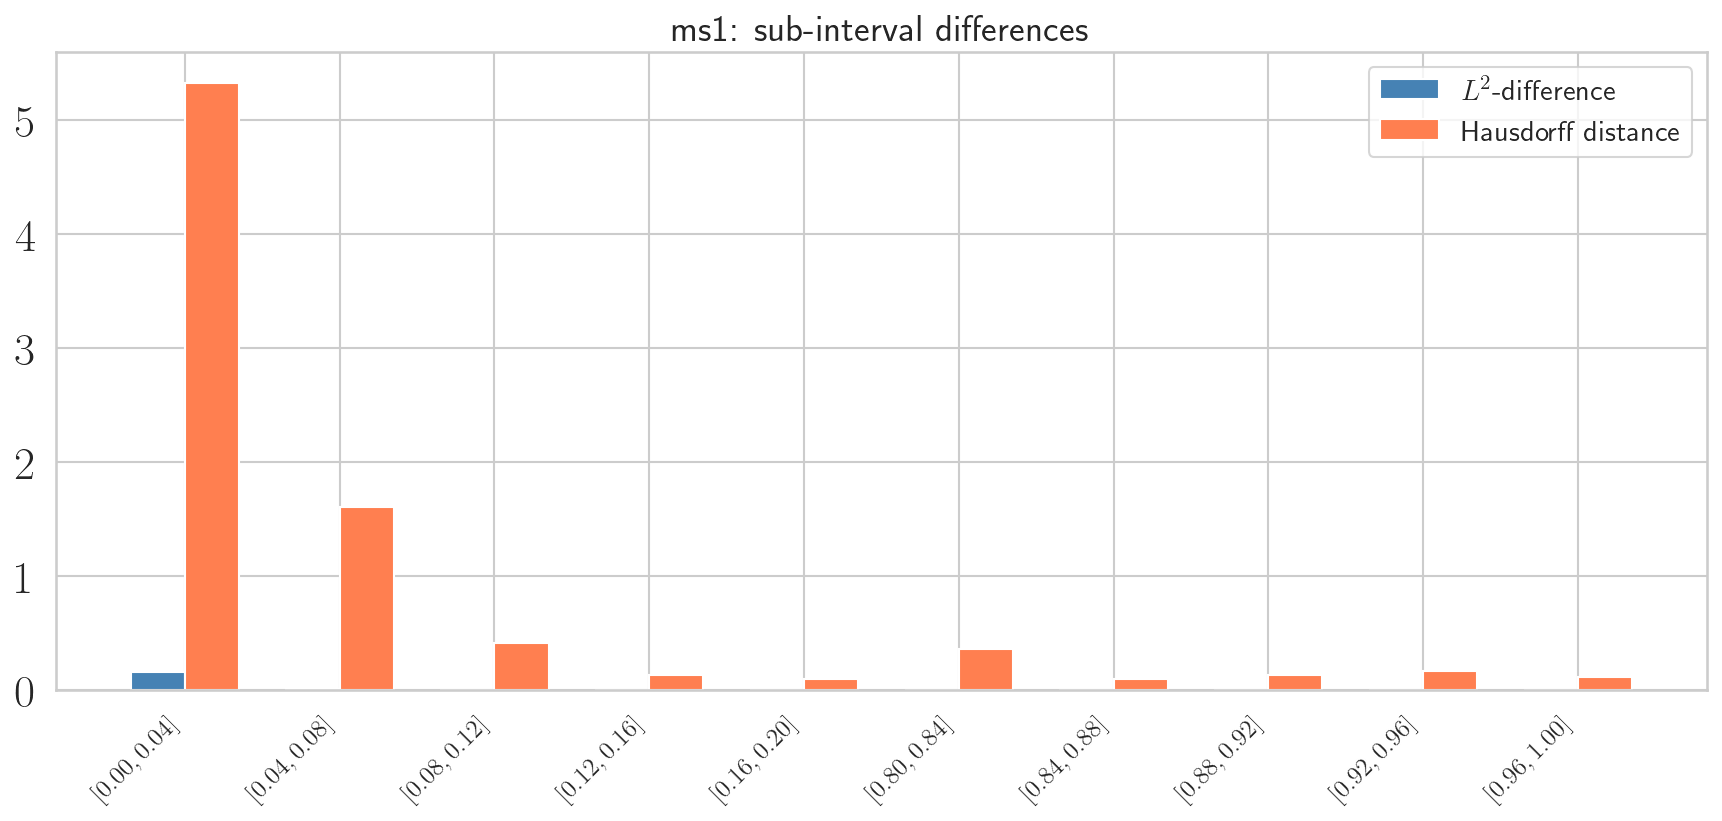

In [26]:
# L2 and Hausdorff difference across each ms1 sub-interval
from scipy.spatial.distance import directed_hausdorff
import numpy as np

path = ms1.path.clone().detach()

x_ranges = {}
x_data = {}
for t_val in sorted(set(path[:, 0].numpy().round(8))):
    mask = torch.abs(path[:, 0] - t_val) < 1e-5
    xs = path[mask, 1]
    if len(xs) > 0:
        x_ranges[t_val] = (xs.min().item(), xs.max().item())
        x_data[t_val] = xs.numpy().reshape(-1, 1)

sub_intervals = []
for interval in ms1_model_params['intervals']:
    a, b = interval
    dt = (b - a) / ms1_model_params['num_time_steps']
    for k in range(ms1_model_params['num_time_steps']):
        sub_intervals.append([a + k * dt, a + (k + 1) * dt])

mse_list = []
hausdorff_list = []
labels = []
num_grid = 200
for sub in sub_intervals:
    a, b = sub
    ta = min(x_ranges.keys(), key=lambda t: abs(t - a))
    tb = min(x_ranges.keys(), key=lambda t: abs(t - b))
    x_lo = max(x_ranges[ta][0], x_ranges[tb][0])
    x_hi = min(x_ranges[ta][1], x_ranges[tb][1])
    if x_lo < x_hi:
        x_grid = torch.linspace(x_lo, x_hi, num_grid)
        tx0 = torch.cat((ta * torch.ones(num_grid, 1), x_grid.unsqueeze(-1)), dim=1)
        tx1 = torch.cat((tb * torch.ones(num_grid, 1), x_grid.unsqueeze(-1)), dim=1)
        v0 = ms1.value(tx0).squeeze(-1).detach()
        v1 = ms1.value(tx1).squeeze(-1).detach()
        mse = torch.mean((v0 - v1) ** 2).item()
    else:
        mse = 0
    mse_list.append(mse)
    d_fwd = directed_hausdorff(x_data[ta], x_data[tb])[0]
    d_bwd = directed_hausdorff(x_data[tb], x_data[ta])[0]
    hausdorff_list.append(max(d_fwd, d_bwd))
    labels.append(f"$[{a:.2f},{b:.2f}]$")
    print(f"[{a:.2f},{b:.2f}]: MSE={mse:.6f}, Hausdorff={hausdorff_list[-1]:.6f}")

x_pos = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
ax.bar(x_pos - width/2, mse_list, width, label=r"$L^2$-difference", color='steelblue')
ax.bar(x_pos + width/2, hausdorff_list, width, label='Hausdorff distance', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)
ax.set_title('ms1: sub-interval differences', fontsize=18)
ax.legend(fontsize=14)
plt.tight_layout()
plt.savefig("/Users/arashfahim/Documents/GitHub/multiscale-PGM-for-stochastic-control/LQC/Three-steps/L2_diff_consecutive_ms1" + version + ".pdf", format='pdf')
plt.show()

In [27]:
# Hausdorff for ms1 merged into cell above

In [28]:
tx1 = torch.concat((torch.zeros([K1,1]), X1.unsqueeze(-1)), dim=1)
dfv_ms = pd.DataFrame(np.zeros([K1*L,3]),columns=[1,'C','closed']); 
for i,_ in dfv_ms.iterrows(): 
    dfv_ms.loc[i,1] = ms1.cost_eval(ms1.policy,1,X1[i%K1]).clone().detach().numpy()
    dfv_ms.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X1[i%K1]).clone().detach().numpy()
dfv_ms['closed'] = list(solution(tx1))*L
dfv_ms['index'] = [str(np.round(x,3)) for x in X1.clone().detach().numpy()]*L
dfv_ms.set_index('index',inplace=True,drop=True)
dfv_ms

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,C,closed
index,,,
-2.0,25.499218,86.445907,13.858620
-1.789,20.530187,69.291598,11.236016
-1.579,17.475925,63.867952,8.907337
-1.368,11.349713,46.548715,6.872583
-1.158,11.545259,35.282050,5.131752
...,...,...,...
1.158,8.939261,30.527865,5.381618
1.368,12.247275,40.058868,7.167879
1.579,18.599861,59.779300,9.248064


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/3513115942.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/3513115942.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


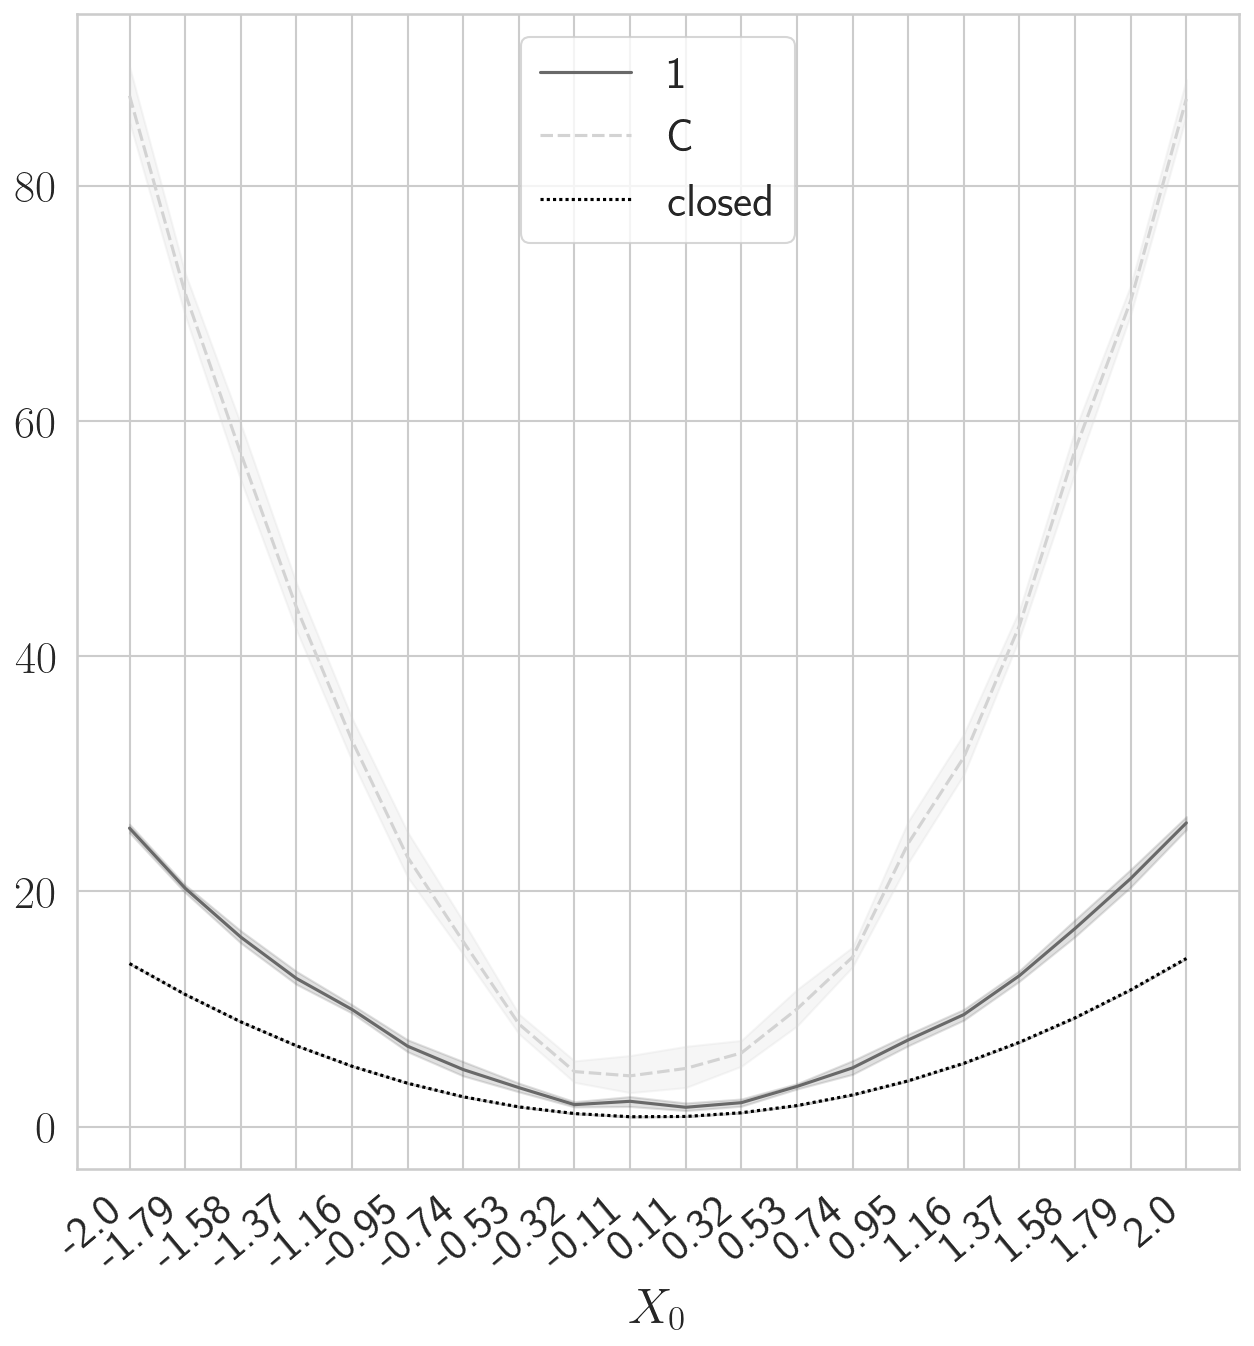

In [29]:
plt.figure(figsize=(10,10),dpi=150);
g = sns.lineplot(data=dfv_ms, palette=['dimgrey', 'lightgrey', 'black']);
g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
g.set_xlabel(r"$X_0$");
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
s1 = str(model_params['num_samples'])
s2 = str(ms1_model_params['num_samples'])
plt.savefig("/Users/arashfahim/Documents/GitHub/multiscale-PGM-for-stochastic-control/LQC/Three-steps/"+s1+"_"+s2+version+".png")

In [30]:
df_ms = pd.DataFrame(np.zeros([K*L,3]),columns=[1,'C','closed']); 
for i,_ in df_ms.iterrows(): 
    df_ms.loc[i,1] = ms1.cost_eval(ms1.policy,1,X[i%K]).clone().detach().numpy()
    df_ms.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X[i%K]).clone().detach().numpy()
df_ms['closed'] = list(solution(tx))*L
df_ms['index'] = [str(np.round(x,3)) for x in X.clone().detach().numpy()]*L
df_ms.set_index('index',inplace=True,drop=True)
df_ms

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,C,closed
index,,,
-10.0,599.473288,2080.703421,331.315435
-7.778,361.050882,1258.039178,200.559325
-5.556,187.369984,648.610120,102.552185
-3.333,66.298323,236.459372,37.294016
-1.111,8.584779,27.129073,4.784816
...,...,...,...
1.111,8.961877,35.066886,5.024587
3.333,68.090960,237.089611,38.013328
5.556,185.130978,645.232934,103.751039


In [31]:
df_box_ms1 = ((df_ms[1]-df_ms['closed'])/df_ms['closed']).reset_index()
df_box_ms1.columns = ['x', 'rel_error']
df_box_ms1['Method'] = 'multi-scale1'
df_box_msc = pd.concat([df_box_ms1,df_box_co],axis=0)
df_box_msc

,x,rel_error,Method
0,-10.0,0.809373,multi-scale1
1,-7.778,0.800220,multi-scale1
2,-5.556,0.827070,multi-scale1
3,-3.333,0.777720,multi-scale1
4,-1.111,0.794171,multi-scale1
...,...,...,...
95,1.111,4.966961,coarse
96,3.333,5.190615,coarse
97,5.556,5.282471,coarse
98,7.778,5.244488,coarse


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/3941098221.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


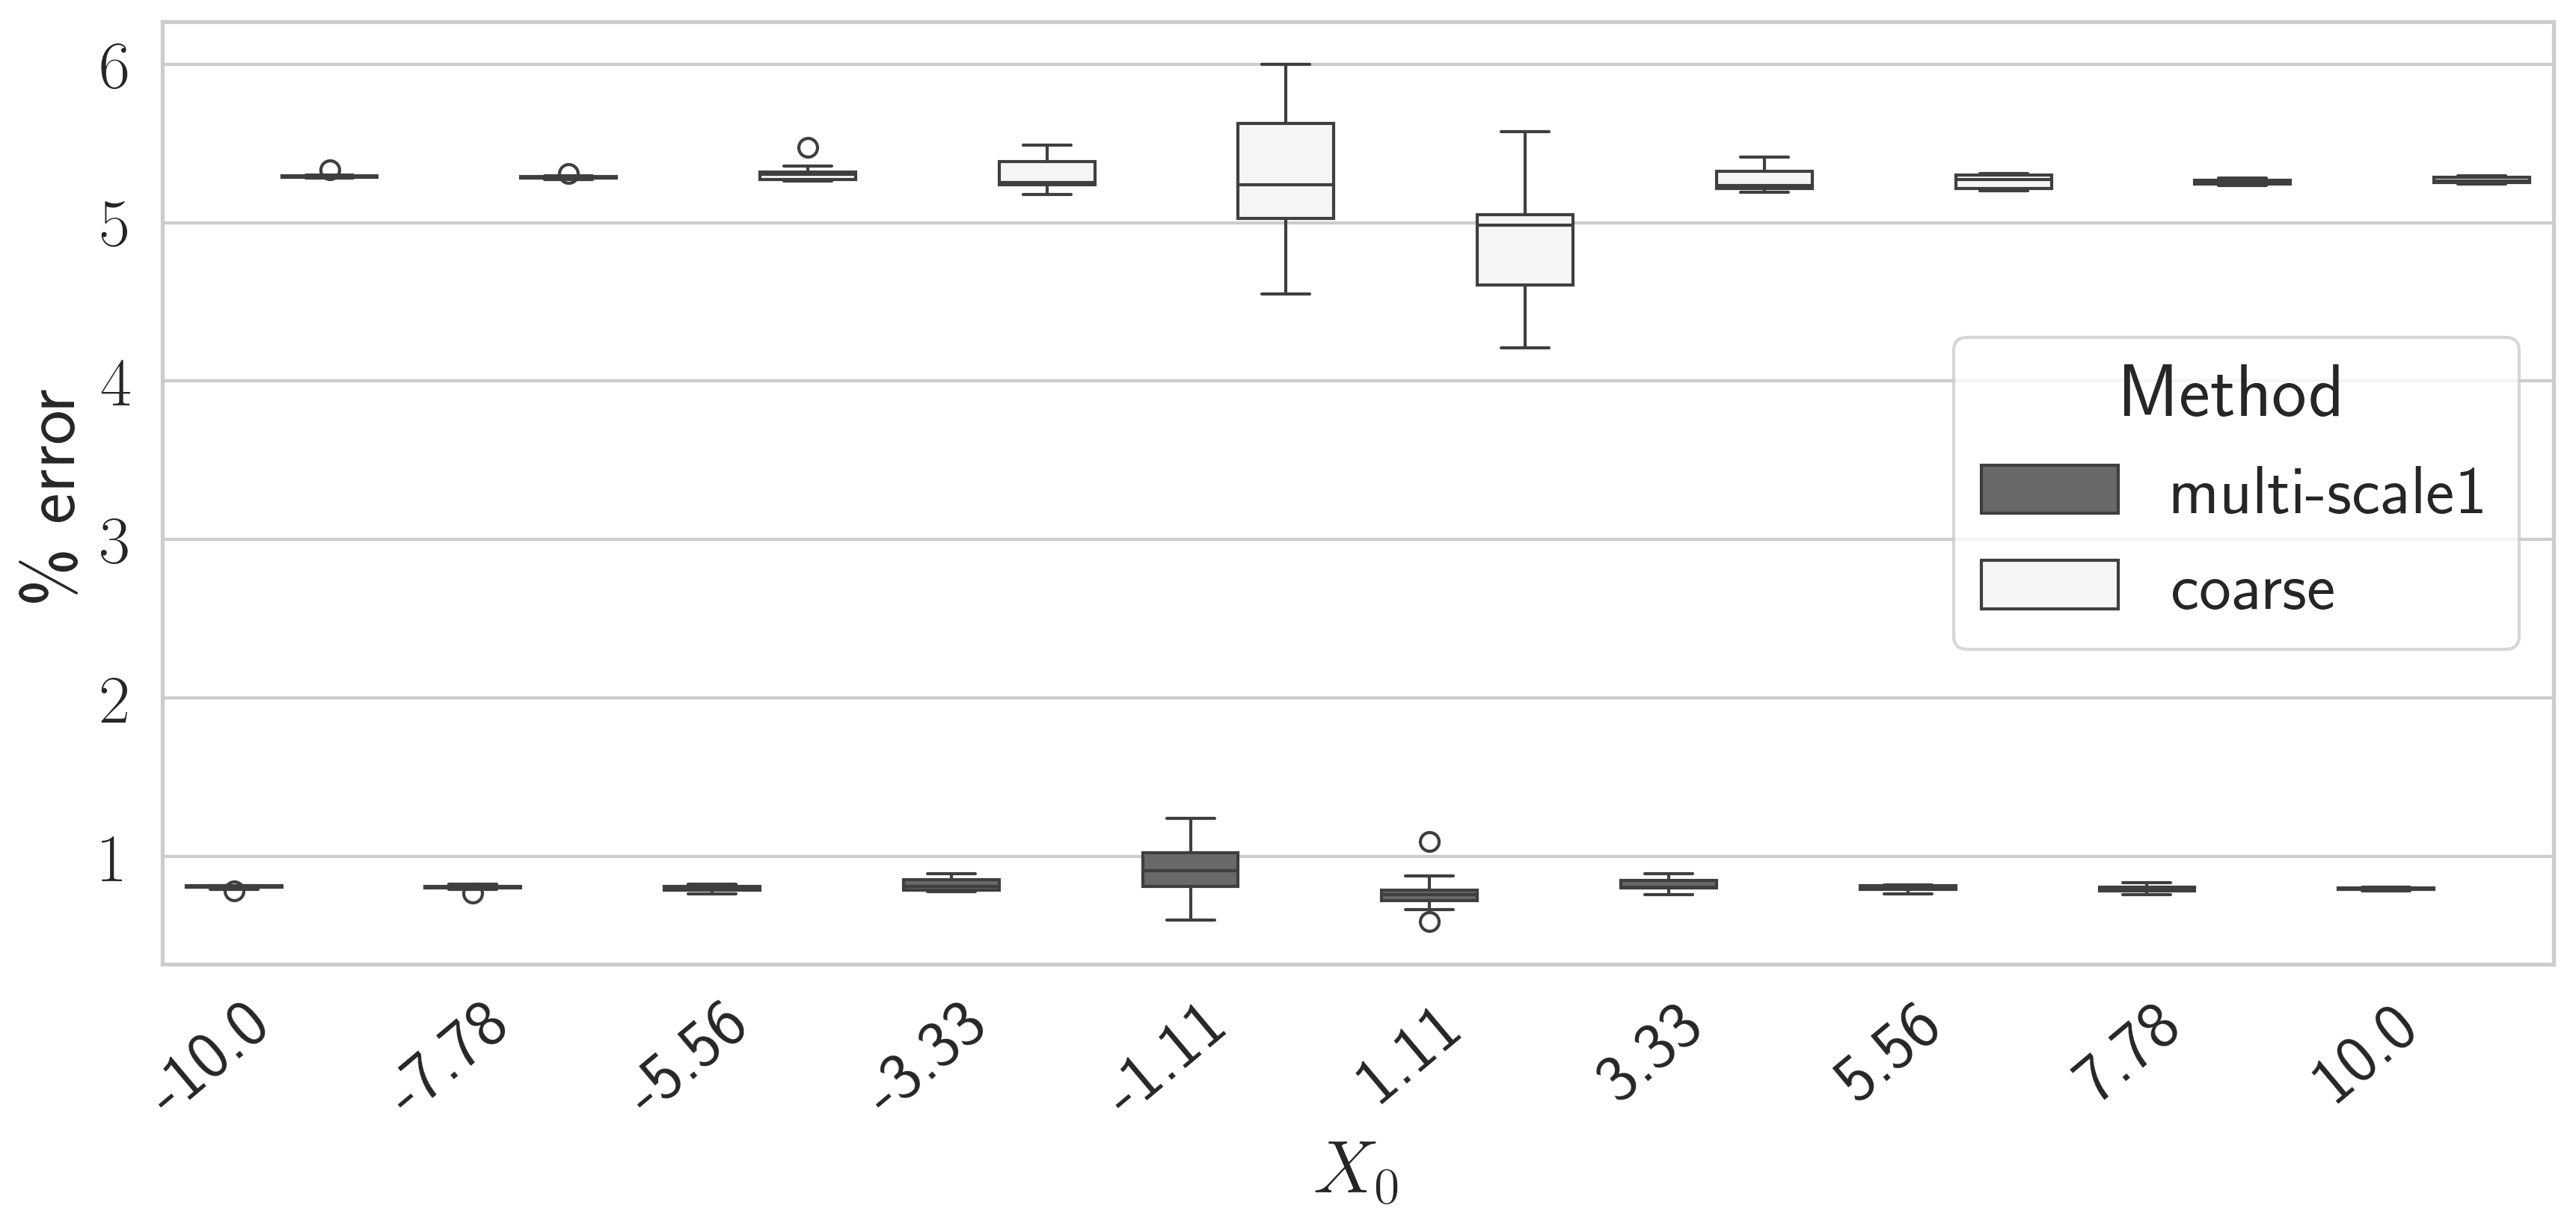

In [32]:
fig = plt.figure(figsize=(12,6),dpi=300);
sns.set_style("whitegrid");
g = sns.boxplot(data=df_box_msc, y = 'rel_error', x = 'x', hue='Method', palette=['dimgrey', 'whitesmoke']);#, boxprops=dict(facecolor='none'));
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
g.set_xlabel(r"$X_0$");
g.set_ylabel(r"\% error");
# g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="center");
plt.tight_layout();

Relative $L^1$ error $= 90.10\%$

Relative $L^2$ error $= 79.69\%$

Relative $L^\infty$ error $= 82.06\%$

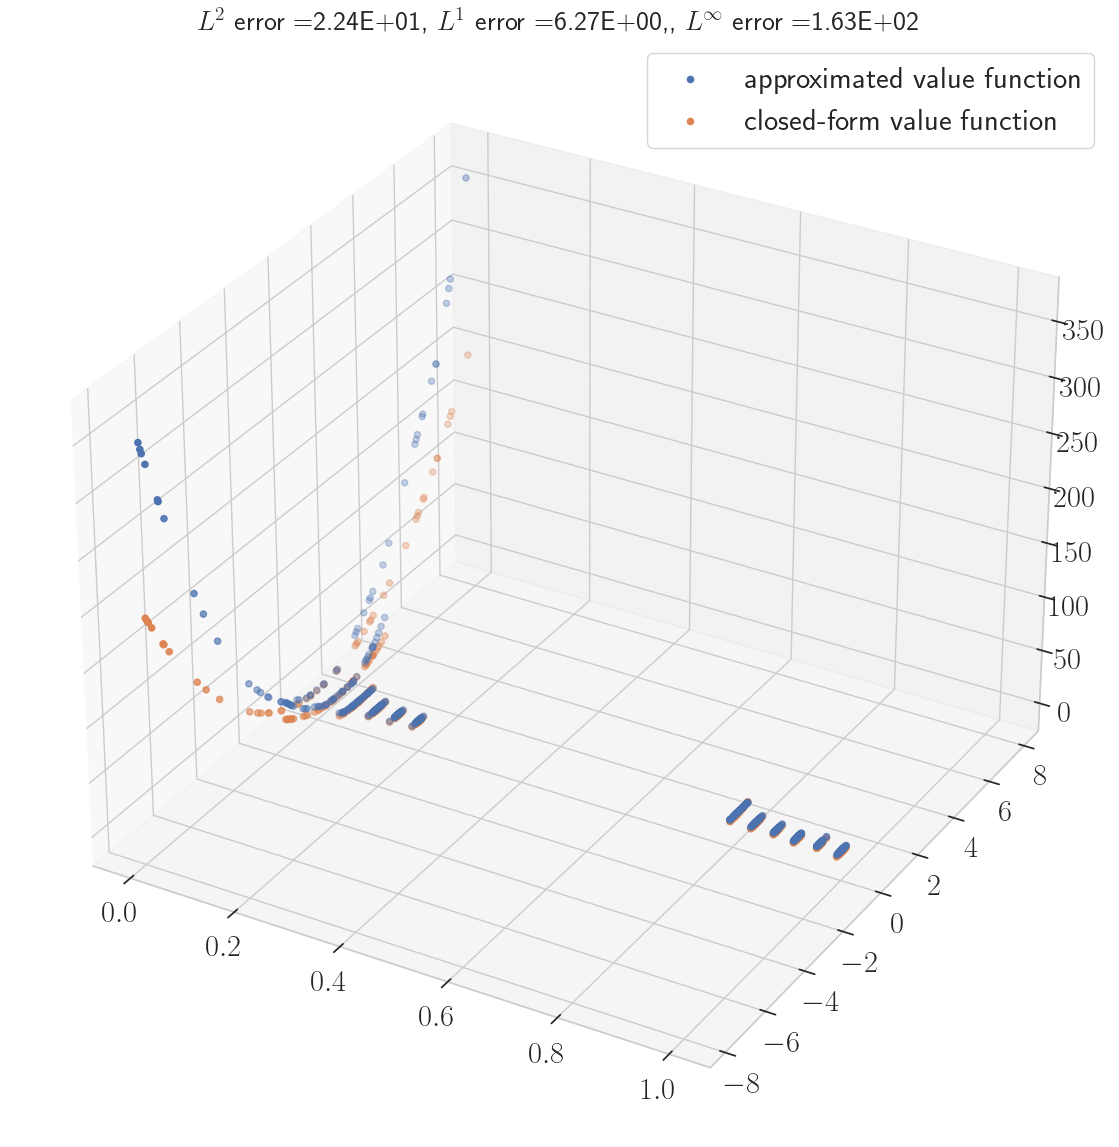

In [33]:
xyz = torch.concat((ms1.path,ms1(ms1.path).unsqueeze(-1)),dim=1).clone().detach().numpy()

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2],label='approximated value function')
ax.scatter(xyz[:,0], xyz[:,1], solution(xyz[:,0:2]),label='closed-form value function')
ax.legend();
ax.set_title(r"$L^2$ error ={:.2E}, $L^1$ error ={:.2E},, $L^\infty$ error ={:.2E}".format(
    np.sqrt(np.mean(np.power(solution(xyz[:,0:2])-xyz[:,2],2))),
    np.mean(np.abs(solution(xyz[:,0:2])-xyz[:,2])),
    np.max(np.abs(solution(xyz[:,0:2])-xyz[:,2])),
    ), fontsize=20)
plt.tight_layout();

display(Markdown(r"Relative $L^1$ error $= {:.2f}\%$".format(np.mean(np.abs(solution(xyz[:,0:2])-xyz[:,2]))/np.mean(np.abs(solution(xyz[:,0:2])))*100)))
display(Markdown(r"Relative $L^2$ error $= {:.2f}\%$".format(np.sqrt(np.mean(np.power(solution(xyz[:,0:2])-xyz[:,2],2)))/np.sqrt(np.mean(np.power(solution(xyz[:,0:2]),2)))*100)))
display(Markdown(r"Relative $L^\infty$ error $= {:.2f}\%$".format(np.max(np.abs(solution(xyz[:,0:2])-xyz[:,2]))/np.max(np.abs(solution(xyz[:,0:2])))*100)))

# Multi-scale PGM 2

## Multi-scale parameters

In [34]:
ms2_model_params = {
    'num_samples':50,
    'num_time_steps':5,
    'num_neurons_p':50,
    'num_neurons_v':10,
    'lr' : 8e-3,
    'num_epochs' : 3000,
    'xmin' : model_params['xmin'],
    'xmax' : model_params['xmax'],
    'intervals' : [[0, 0.04], [0.04, 0.08], [0.8, 0.84], [0.84, 0.88]], # first two sub-intervals of each ms1 interval
    'data': ms1.path_full
    }


## instance creation

In [35]:
ms2 = multi_scale_pgm(ms2_model_params,lqsc_params, ms1, value_eval=False)

## Training

In [36]:
ms2.train_it()

At epoch 0 the mean cost is 55.064627373017174.


At epoch 500 the mean cost is 20.860531463177153.


At epoch 1000 the mean cost is 20.84722932869211.


At epoch 1500 the mean cost is 20.844744143486437.


At epoch 2000 the mean cost is 20.843563740034195.


At epoch 2500 the mean cost is 20.842405620028238.


Training time= 3.309962034225464


In [37]:
ms2_model_params['intervals']

[[0, 0.04], [0.04, 0.08], [0.8, 0.84], [0.84, 0.88]]

In [38]:
dfv_ms = pd.DataFrame(np.zeros([K1*L,3]),columns=[1,'C','closed']); 
for i,_ in dfv_ms.iterrows(): 
    dfv_ms.loc[i,1] = ms1.cost_eval(ms1.policy,1,X1[i%K1]).clone().detach().numpy()
    dfv_ms.loc[i,2] = ms2.cost_eval(ms2.policy,1,X1[i%K1]).clone().detach().numpy()
    dfv_ms.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X1[i%K1]).clone().detach().numpy()
dfv_ms['closed'] = list(solution(tx1))*L
dfv_ms['index'] = [str(np.round(x,3)) for x in X1.clone().detach().numpy()]*L
dfv_ms.set_index('index',inplace=True,drop=True)
dfv_ms

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,C,closed,2
index,,,,
-2.0,25.691159,86.401371,13.858620,15.070789
-1.789,20.612608,72.118961,11.236016,15.197384
-1.579,15.806841,54.536594,8.907337,9.254154
-1.368,12.818315,43.990735,6.872583,8.085686
-1.158,10.241728,37.869363,5.131752,6.423677
...,...,...,...,...
1.158,8.907367,37.108312,5.381618,7.252764
1.368,14.508135,45.954989,7.167879,6.816761
1.579,15.285013,62.092698,9.248064,10.824318


In [39]:
dfv_ms.loc[dfv_ms.index[150]]

,1,C,closed,2
index,,,,
0.105,1.992775,4.284072,0.859179,2.310080
0.105,1.912259,8.318213,0.859179,0.934563
0.105,1.502498,3.651685,0.859179,0.853435
0.105,1.667551,3.094404,0.859179,1.225531
0.105,1.033406,2.683114,0.859179,2.401342
0.105,0.837903,1.720181,0.859179,1.195716
0.105,1.270669,3.876062,0.859179,1.244022
0.105,1.724400,1.291256,0.859179,0.502974
0.105,1.071169,1.771788,0.859179,0.591060


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1326709250.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1326709250.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


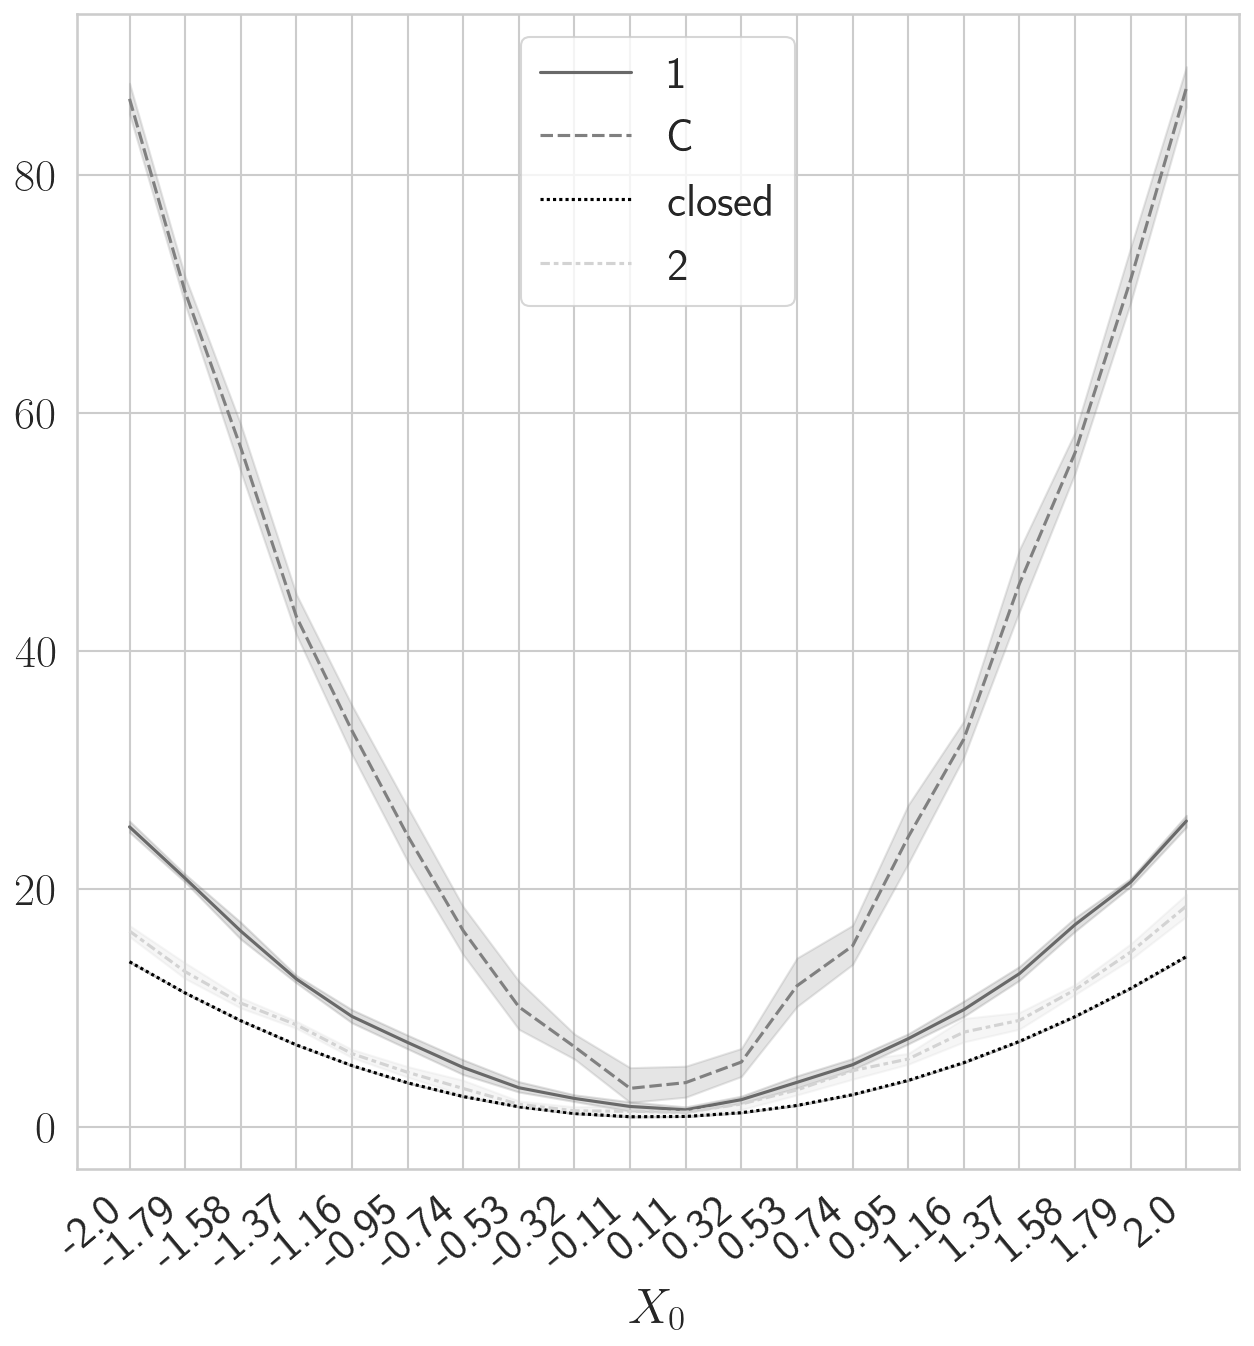

In [40]:
plt.figure(figsize=(10,10),dpi=150);
g = sns.lineplot(data=dfv_ms, palette=['dimgrey', 'grey', 'black', 'lightgrey']);
g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
g.set_xlabel(r"$X_0$");
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
s1 = str(model_params['num_samples'])
s2 = str(ms1_model_params['num_samples'])
plt.savefig("/Users/arashfahim/Documents/GitHub/multiscale-PGM-for-stochastic-control/LQC/Three-steps/"+s1+"_"+s2+version+".png")

In [41]:
df_ms2 = pd.DataFrame(np.zeros([K*L,4]),columns=[1,2,'C','closed']); 
for i,_ in df_ms2.iterrows(): 
    df_ms2.loc[i,1] = ms1.cost_eval(ms1.policy,1,X[i%K]).clone().detach().numpy()
    df_ms2.loc[i,2] = ms2.cost_eval(ms2.policy,1,X[i%K]).clone().detach().numpy()
    df_ms2.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X[i%K]).clone().detach().numpy()
df_ms2['closed'] = list(solution(tx))*L
df_ms2['index'] = [str(np.round(x,3)) for x in X.clone().detach().numpy()]*L
df_ms2.set_index('index',inplace=True,drop=True)
df_ms2


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,2,C,closed
index,,,,
-10.0,595.388920,373.606240,2091.235067,331.315435
-7.778,366.480490,225.263005,1258.297046,200.559325
-5.556,189.337045,116.152791,646.860925,102.552185
-3.333,66.258081,43.437724,238.910665,37.294016
-1.111,8.875118,5.241721,31.831243,4.784816
...,...,...,...,...
1.111,10.223078,9.000137,31.492433,5.024587
3.333,67.969730,49.844181,238.908156,38.013328
5.556,185.626348,117.539439,643.444872,103.751039


In [42]:
df_box_ms2 = ((df_ms2[2]-df_ms2['closed'])/df_ms2['closed']).reset_index()
df_box_ms2.columns = ['x', 'rel_error']
df_box_ms2['Method'] = 'multi-scale2'
# df_box_ms = pd.concat([df_box_ms1,df_box_ms2],axis=0)
df_box_msc2 = pd.concat([df_box_ms2,df_box_msc],axis=0)
df_box_msc2['x'] = df_box_msc2['x'].astype('float64')

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/3031217305.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


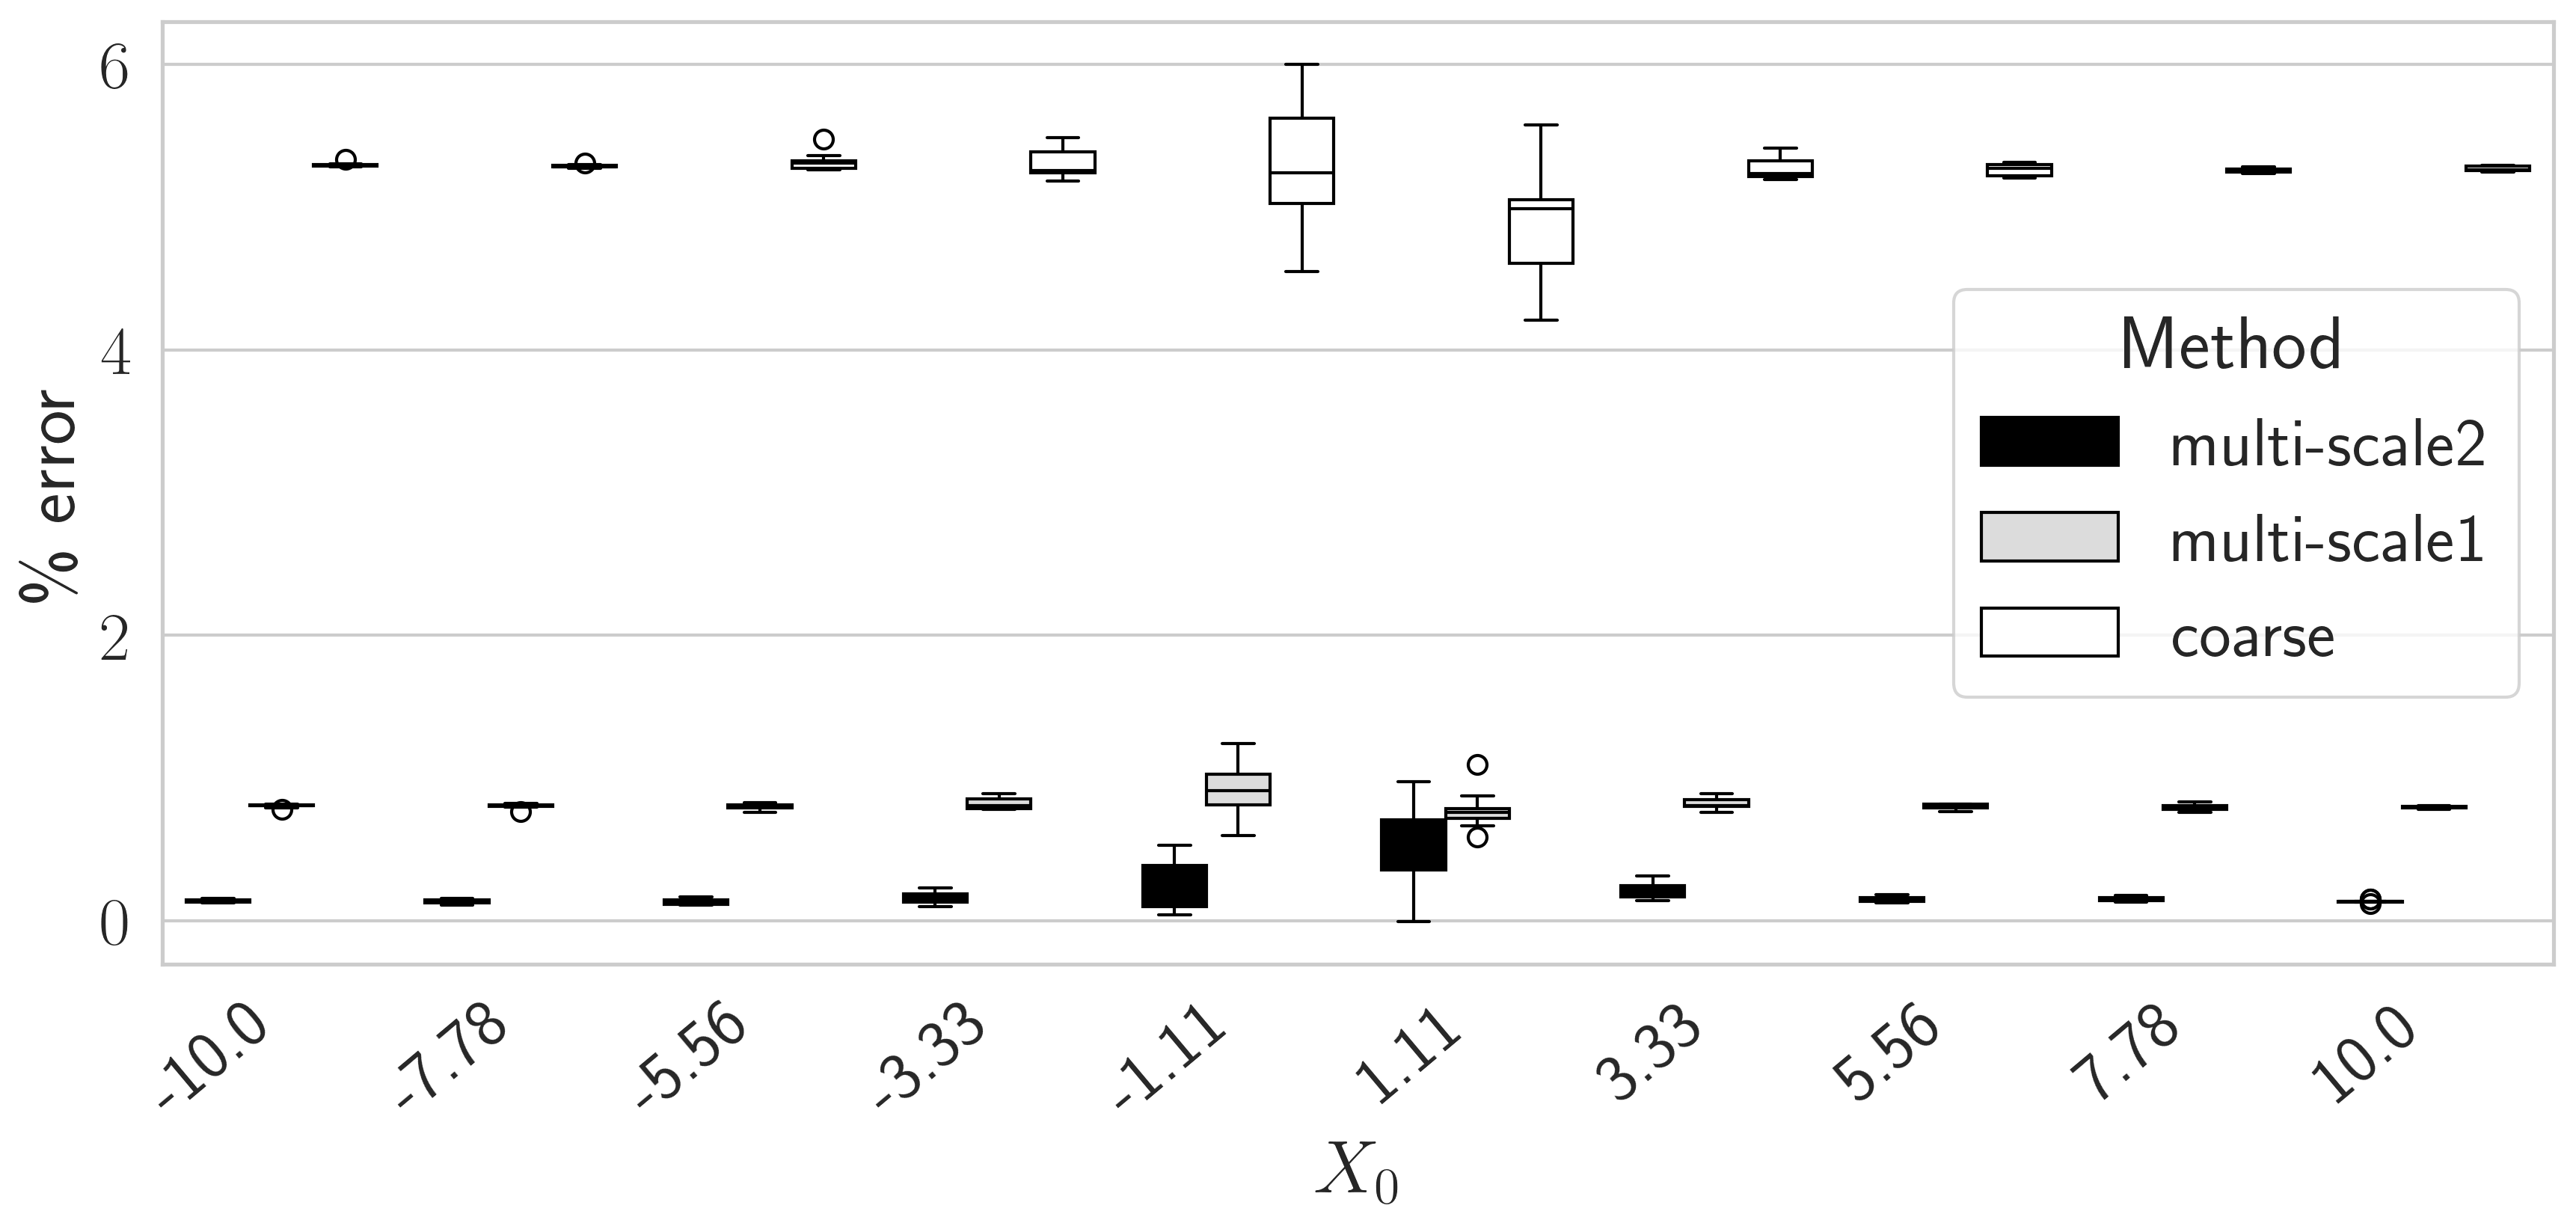

In [43]:
fig = plt.figure(figsize=(12,6),dpi=300);
sns.set_style("whitegrid");
g = sns.boxplot(data=df_box_msc2, y = 'rel_error', x = 'x', hue='Method', palette=[ 'black', 'gainsboro', 'white']);#, boxprops=dict(facecolor='none'));
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
g.set_xlabel(r"$X_0$");
g.set_ylabel(r"\% error");
# g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="center");
plt.tight_layout();

# Brute-force

## Parameters

In [44]:
bf_model_params = {
    'num_samples':100,
    'num_time_steps':ms2.Num_steps,
    'num_neurons_p':50,
    'num_neurons_v':10,
    'lr' : 8e-3,
    'num_epochs' : 3000,
    'xmin' : model_params['xmin'],
    'xmax' : model_params['xmax'],
    'intervals' : None # a list of numbers between 0 to num_intervals-1
    }

## Instance creation

In [45]:
bf_lqsc = pgm(bf_model_params,lqsc_params, t1, value_eval=False)

## Training

In [46]:
bf_lqsc.train_it()

At epoch 0 the mean cost is 19584.422733376454.


At epoch 500 the mean cost is 138.5865503115756.


At epoch 1000 the mean cost is 137.46559231401008.


At epoch 1500 the mean cost is 137.44708876992402.


At epoch 2000 the mean cost is 137.44474484053512.


At epoch 2500 the mean cost is 137.4439795913323.


Training time= 75.17047214508057


In [47]:
dfv_bf = pd.DataFrame(np.zeros([K1*L,5]),columns=[1,'closed','C','MS1', 'MS2']); 
for i,_ in dfv_bf.iterrows(): 
    # df_bf.loc[i,10] = bf_lqsc.cost_eval(lqsc.policy,3000,X[i%K],policy_update_lag=10).clone().detach().numpy()
    dfv_bf.loc[i,1] = bf_lqsc.cost_eval(bf_lqsc.policy,1,X1[i%K1]).clone().detach().numpy()
    dfv_bf.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X1[i%K1]).clone().detach().numpy()
    dfv_bf.loc[i,'MS1'] = ms1.cost_eval(ms1.policy,1,X1[i%K1]).clone().detach().numpy()
    dfv_bf.loc[i,'MS2'] = ms2.cost_eval(ms2.policy,1,X1[i%K1]).clone().detach().numpy()    
dfv_bf['closed'] = list(solution(tx1))*L
dfv_bf['index'] = [str(np.round(x,3)) for x in X1.clone().detach().numpy()]*L
dfv_bf.set_index('index',inplace=True,drop=True)    
dfv_bf.rename(columns={1:'brute-force', 'closed':'closed-form','C':'coarse', 'MS1': 'multi-scale1', 'MS2': 'multi-scale2'},inplace=True)


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1896444185.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1896444185.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


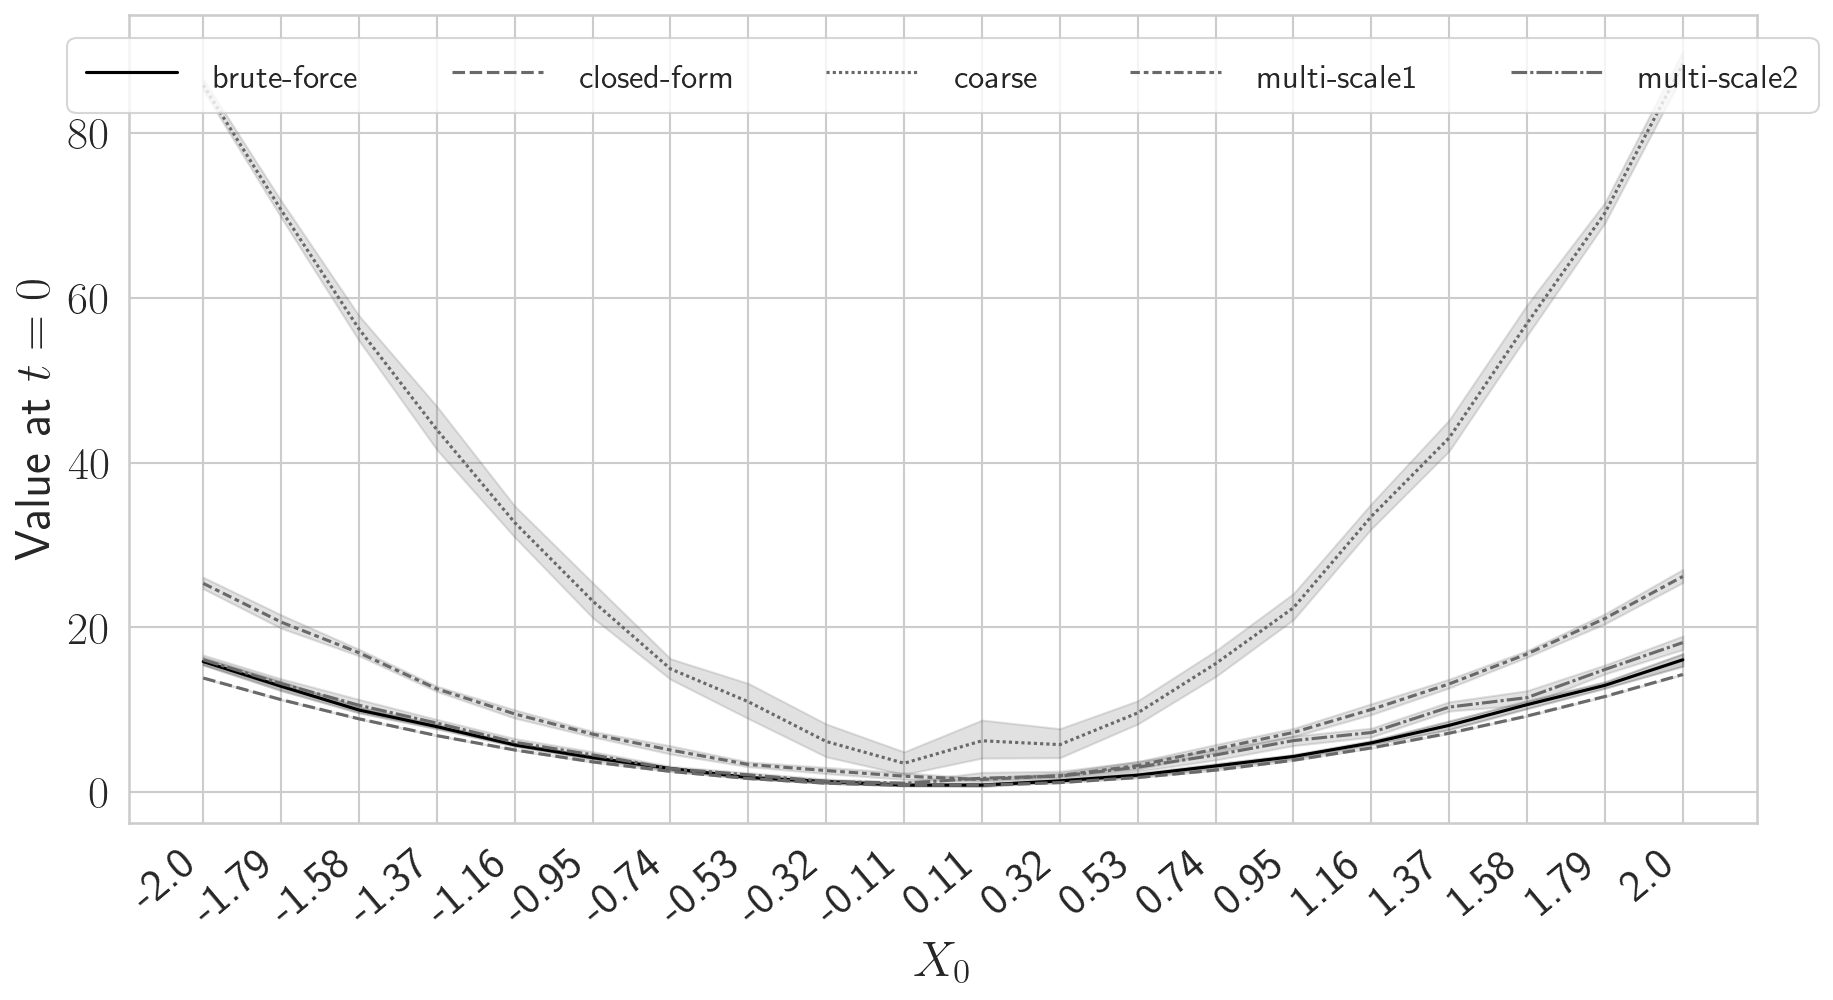

In [48]:
plt.figure(figsize=(14,7),dpi=150);
sns.set_style("whitegrid");
g = sns.lineplot(data=dfv_bf, palette=['black', 'dimgrey', 'dimgrey', 'dimgrey','dimgrey']);
g.set_xticklabels(list(np.round(X1.clone().detach().numpy(),2)));
g.set_xlabel(r"$X_0$");
g.set_ylabel(r"Value at $t=0$");
sns.move_legend(g, "upper center", bbox_to_anchor=(.5, 1.), ncol=5, title=None)
plt.setp(g.get_legend().get_texts(), fontsize='16') # for legend text
plt.setp(g.get_legend().get_title(), fontsize='12') # for legend title
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
s1 = str(model_params['num_samples'])
s2 = str(ms1_model_params['num_samples'])
plt.savefig("/Users/arashfahim/Documents/GitHub/multiscale-PGM-for-stochastic-control/LQC/Three-steps/bf_"+s1+"_"+s2+version+".png")

In [49]:
df_bf = pd.DataFrame(np.zeros([K*L,5]),columns=[1,'closed','C','MS1', 'MS2']); 
for i,_ in df_bf.iterrows(): 
    # df_bf.loc[i,10] = bf_lqsc.cost_eval(lqsc.policy,3000,X[i%K],policy_update_lag=10).clone().detach().numpy()
    df_bf.loc[i,1] = bf_lqsc.cost_eval(bf_lqsc.policy,1,X[i%K]).clone().detach().numpy()
    df_bf.loc[i,'C'] = lqsc.cost_eval(lqsc.policy,1,X[i%K]).clone().detach().numpy()
    df_bf.loc[i,'MS1'] = ms1.cost_eval(ms1.policy,1,X[i%K]).clone().detach().numpy()
    df_bf.loc[i,'MS2'] = ms2.cost_eval(ms2.policy,1,X[i%K]).clone().detach().numpy()
df_bf['closed'] = list(solution(tx))*L
df_bf['index'] = [str(np.round(x,3)) for x in X.clone().detach().numpy()]*L
df_bf.set_index('index',inplace=True,drop=True)    
df_bf

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.f_func = lambda t: -1/q2*(lb1*np.exp(lb1*(self.T-t))+C1*lb2*np.exp(lb2*(self.T-t)))/(np.exp(lb1*(self.T-t))+C1*np.exp(lb2*(self.T-t)))
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.array([self.f_func(tx[i,0])*np.power(tx[i,1],2)+self.h_func(tx[i,0])*tx[i,1]+self.k_func(tx[i,0]) for i in range(tx.shape[0])])
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/1048887168.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  self.h_func = lambda t: (self.b*((1/(lb1-self.c))*np.exp(lb

,1,closed,C,MS1,MS2
index,,,,,
-10.0,372.581301,331.315435,2085.724435,593.063467,374.277706
-7.778,226.391703,200.559325,1260.777257,359.959102,230.427957
-5.556,113.483388,102.552185,642.937808,187.363639,114.037408
-3.333,40.698566,37.294016,232.379876,68.655768,41.558434
-1.111,5.158651,4.784816,30.414029,8.649880,5.919200
...,...,...,...,...,...
1.111,6.029410,5.024587,31.686849,8.092081,6.974507
3.333,42.301162,38.013328,242.880393,69.258440,44.561908
5.556,119.540103,103.751039,649.166418,189.471924,121.701425


In [50]:
df_box_bf = ((df_bf[1]-df_bf['closed'])/df_bf['closed']).reset_index()
df_box_bf.columns = ['x', 'rel_error']
df_box_bf['Method'] = 'brute-force'
df_box_bfmsc = pd.concat([df_box_bf,df_box_msc2],axis=0)
df_box_bfmsc

,x,rel_error,Method
0,-10.0,0.124552,brute-force
1,-7.778,0.128802,brute-force
2,-5.556,0.106592,brute-force
3,-3.333,0.091289,brute-force
4,-1.111,0.078129,brute-force
...,...,...,...
95,1.111,4.966961,coarse
96,3.333,5.190615,coarse
97,5.556,5.282471,coarse
98,7.778,5.244488,coarse


/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_17543/2992011261.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")


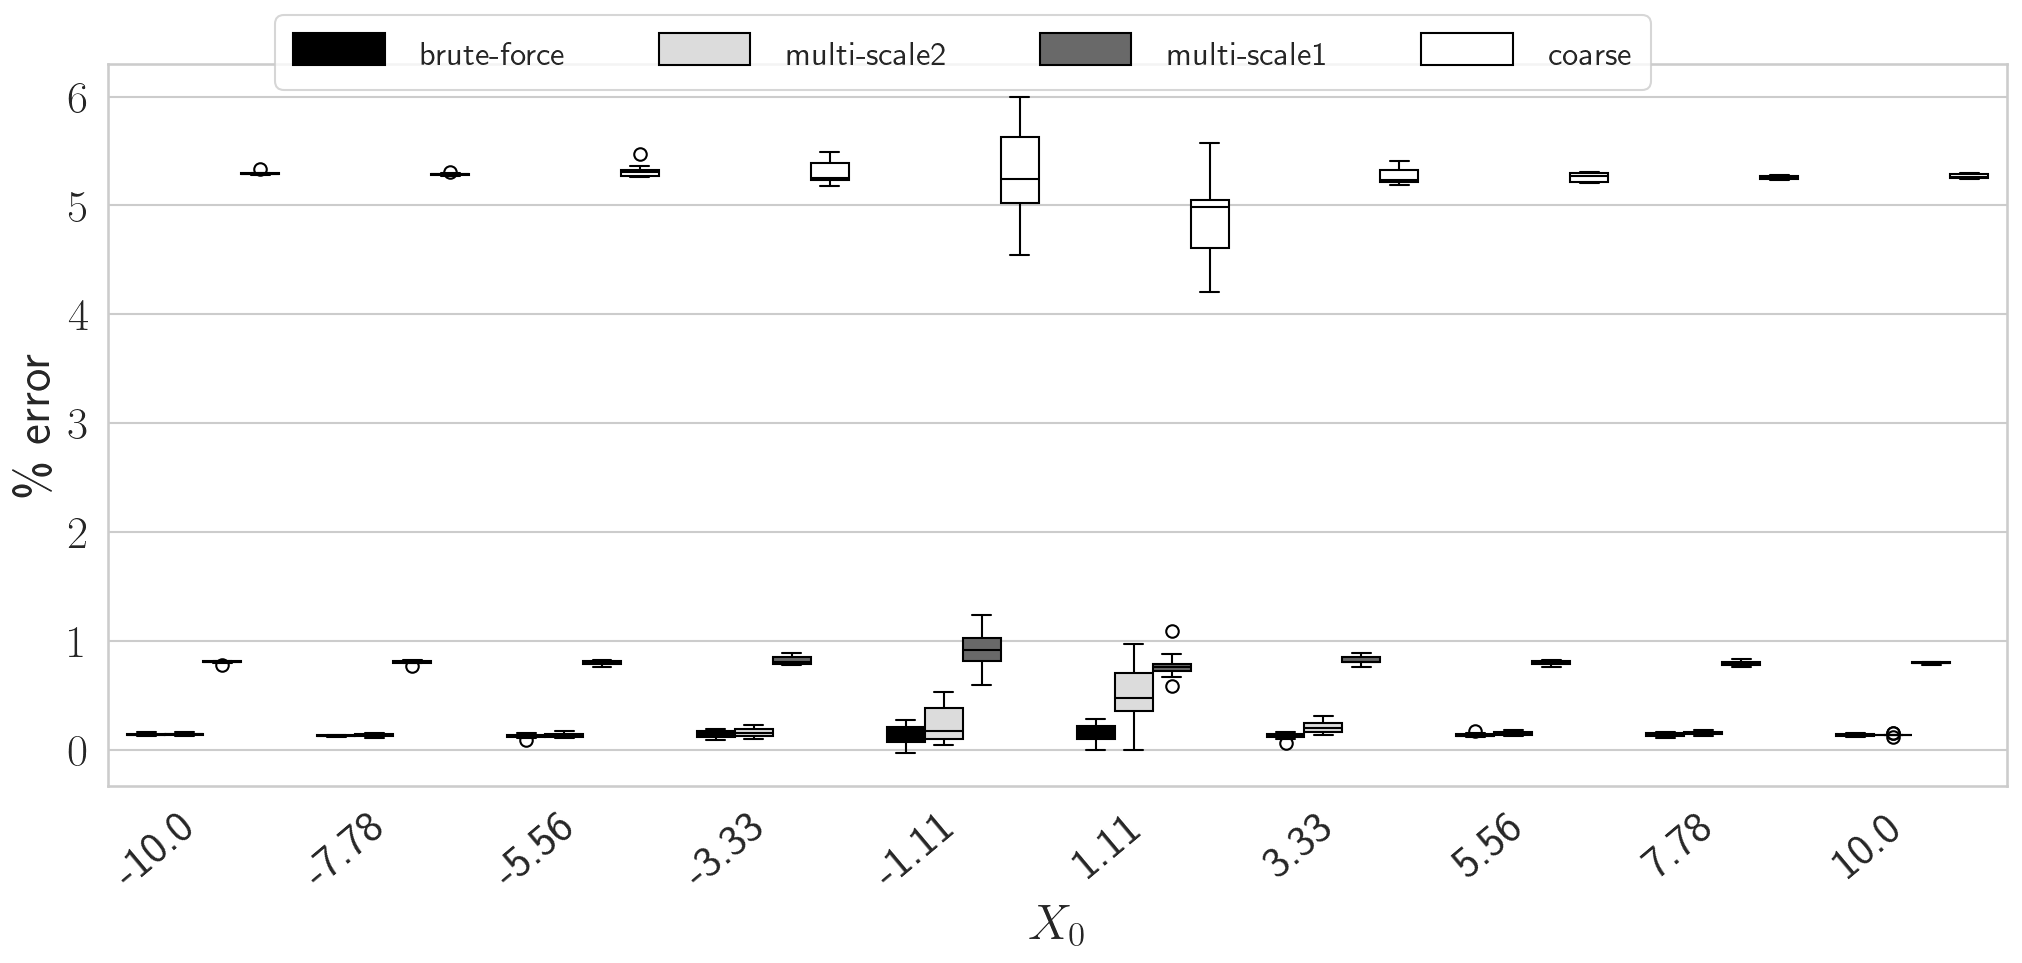

In [51]:
fig = plt.figure(figsize=(14,7),dpi=150);
sns.set_style("whitegrid");
g = sns.boxplot(data=df_box_bfmsc, y = 'rel_error', x = 'x', hue='Method', palette=['black', 'gainsboro', 'dimgrey', 'white']);#, boxprops=dict(facecolor='none'));
g.set_xticklabels([np.round(float(t.get_text()),2)  for t in g.get_xticklabels()], rotation=40, ha="right")
g.set_xlabel(r"$X_0$");
g.set_ylabel(r"\% error");
sns.move_legend(g, "upper center", bbox_to_anchor=(.45, 1.1), ncol=4, title=None)
plt.setp(g.get_legend().get_texts(), fontsize='16') # for legend text
plt.setp(g.get_legend().get_title(), fontsize='12') # for legend title
plt.tight_layout();
plt.savefig("/Users/arashfahim/Documents/GitHub/multiscale-PGM-for-stochastic-control/LQC/Three-steps/rel_{}_{}_{}_Comparison_bf_ms2_coarse{}.png".format(model_params['num_samples'],ms1_model_params['num_samples'],ms2_model_params['num_samples'],version));
plt.savefig("/Users/arashfahim/Documents/GitHub/multiscale-PGM-for-stochastic-control/LQC/Three-steps/rel_{}_{}_{}_Comparison_bf_ms2_coarse{}.pdf".format(model_params['num_samples'],ms1_model_params['num_samples'],ms2_model_params['num_samples'],version), format='pdf');

In [52]:
print("rel_{}_{}_Comparison_bf_ms_coarse{}.pdf".format(model_params['num_samples'],ms1_model_params['num_samples'],version))

rel_100_50_Comparison_bf_ms_coarse_8.pdf
